<a href="https://colab.research.google.com/github/bru401/Main/blob/main/Data_Analytics/MVP_PUC-Rio/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(Bruno_Reis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas
## Análise Exploratória do Crime no Rio de Janeiro


**Nome:** Bruno Renaux Mendes Reis

**Matrícula:** 4052025001668

**Datasets:** [Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003](https://www.ispdados.rj.gov.br/estatistica.html)

[População: série anual por área de delegacia (2000 a 2022)](https://www.ispdados.rj.gov.br/Populacao.html)



# Descrição do Problema

Como carioca desde o nascimento, estou bastante consciente da reputação da minha cidade como uma zona de risco por conta da alta criminalidade. Certamente há estatísticas que comprovam esta narrativa, mas ao me deparar com o dataset descrito a seguir, encontrei-me com a oportunidade de investigar como **realmente** é segurança pública da minha cidade, sem exageros ou negligências.

O dataset escolhido é uma série histórica que registra, por mês e por local, as contagens de uma variedade de crimes dentro do estado do Rio de Janeiro - embora este trabalho em si contemple apenas o crime na capital. Este será complementado por um dataset que contribui com a população destas localidades, uma adição necessária para avaliar a incidência relativa da criminalidade.

*O objetivo principal é investigar as tendências histórias a respeito do tipo e a localidade do crime, e fazer o preparo necessário para a predição destas tendências via treinamento de modelo de regressão. Neste notebook serão realizadas apenas as etapas de análise de dados e pré-processamento.*

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **O crime no Rio de Janeiro proliferou acima do crescimento populacional, como muitos pensam? Se sim, onde? Em quais categorias?**

2. **Haveriam localidades 'outlier' em que o crime excede consideravelmente a média da sua respectiva zona?**

3. **A composição da criminalidade é significativamente diferente entre zonas?**

## Tipo de Problema

Este é um problema de aprendizado **supervisionado** de **regressão**. O dataset consiste essencialmente de variáveis numéricas, com a excessão das colunas que registram o momento no tempo e o local dos registros, e com estes torna-se possível analisar as tendências de tais variáveis nas dimensões temporais e espaciais.

## Seleção de Dados

Ambos os datasets **"Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003"** e **"População: série anual por área de delegacia (2000 a 2022)"** estão disponíveis livremente no site do ISPDados, uma página de dados abertos do [Instituto de Segurança Pública](https://www.ispdados.rj.gov.br/), orgão do governo do estado do Rio de Janeiro.

## Atributos do Dataset

O dataset de estatísticas de segurança contém 36629 linhas e possui 54 atributos relacionados ao crime, organizados em 8 categorias:

- ***Crimes Violentos***:
Homicídio doloso, Lesão corporal seguida de morte, Latrocínio (roubo seguido de morte), Crimes Violentos Letais Intencionais (cvli), Morte por intervenção de agente do Estado, Letalidade violenta, Tentativa de homicídio,  Lesão corporal dolosa,  Estupro.

- ***Crimes de Trânsito***: Homicídio culposo (trânsito), Lesão corporal culposa (trânsito).

- ***Roubos***: Roubo a transeunte, Roubo de telefone celular, Roubo em coletivo, Roubo de veículo, Roubo de carga, Roubo a estabelecimento comercial, Roubo a residência, Roubo a banco, Roubo de caixa eletrônico, Roubo com condução da vítima para saque em instituição financeira, Roubo após saque em instituição financeira, Roubo de bicicleta, Outros roubos que não os listados acima.

- ***Furtos***: Furto de veículo, Furto a transeunte, Furto em coletivo, Furto de telefone celular, Furto de bicicleta, Outros furtos que não os listados acima.

- ***Outros crimes contra o patrimônio***: Extorsão mediante sequestro (sequestro clássico), Extorsão, Extorsão com momentânea privação da liberdade (sequestro relâmpago), Estelionato.

- ***Atividade Policial***: Apreensão de drogas, Número de registros que possuem algum título referente a posse de drogas
Número de registros que possuem algum título referente a tráfico de drogas, Número de registros que possuem algum título referente a apreensão de drogas sem autor, Recuperação de veículo, Auto de Prisão em Flagrante, Auto de Apreensão de Adolescente por Prática de Ato Infracional, Cumprimento de Mandado de Prisão, Cumprimento de Mandado de Busca e Apreensão.

- ***Outros Registros***: Ameaça, Pessoas desaparecidas, Encontro de cadáver, Encontro de ossada, Policiais Militares mortos em serviço, Policiais Civis mortos em serviço.

- ***Registro de ocorrências***

Um dicionário extenso de cada tipo de registro pode ser encontrado [aqui](https://www.ispdados.rj.gov.br/Notas.html)

<br>

### Divisões Territoriais
As divisões territoriais são demarcadas pelas colunas RISP, AISP e CISP:

- ***Regiões Integradas de Segurança Pública (RISP)***: as maiores divisões. São sete as RISPs do estado, com as RISP 1 e 2 pertencendo ao município do Rio.

- ***Áreas Integradas de Segurança Pública (AISP)***: as divisões intermediárias. Serve para a coordenação das políciais civil e militar.

- ***Circunscrições Integradas de Segurança Pública (CISP)***: são as divisões mais granulares, tipicamente contendo de 2 a 5 bairros. Relacionadas às delegacias.

- ***Zonas***: (dimensão adicionada ao dataset por mim) a cidade do Rio de janeiro é dividida entre quatro (recentemente cinco) zonas, bastante distintas e bem reconhecidas pelos moradores da cidade.


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms # para tratamento de missings
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
## Transformações Numéricas e Categóricas
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# Guardando o dataset em um dataframe

# Estatísticas de segurança: série histórica mensal por área de delegacia desde 01/2003
df_estado = pd.read_csv("https://github.com/bru401/Main/raw/refs/heads/main/Data_Analytics/MVP_PUC-Rio/BaseDPEvolucaoMensalCisp.csv", sep=';', encoding = 'ISO-8859-1')

# População: série anual por área de delegacia (2000 a 2022)
dfpop = pd.read_csv("https://raw.githubusercontent.com/bru401/Main/refs/heads/main/Data_Analytics/MVP_PUC-Rio/PopulacaoEvolucaoAnualCisp.csv", sep=';', encoding = 'ISO-8859-1')

In [4]:
# Primeiras linhas (estatísticas de segurança)
df_estado.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [5]:
# Primeiras linhas (população)
dfpop.head()

,circ,ano,pop
0,1,2000,1516
1,4,2000,29229
2,5,2000,34985
3,6,2000,74835
4,7,2000,37931


In [6]:
dfpop.tail(5)

,circ,ano,pop
3060,159,2022,"59922,48804"
3061,165,2022,"44552,17238"
3062,166,2022,"204425,3032"
3063,167,2022,"43542,7503"
3064,168,2022,"18894,36465"


Note que os dados de população só chegam até 2022, enquanto os de crimes chegam a 2026. Não é um grande problema, visto que a população não muda tão rápido assim, mas é importante considerar isso.

O que *é* um problema é que população deveria ser um número inteiro.

In [7]:
dfpop.dtypes

,0
circ,int64
ano,int64
pop,object


In [8]:
# Passamos de string para float, arredondamos os valores e passamos de float para integer
dfpop['pop'] = (
    dfpop['pop']
    .str.replace(',', '.', regex=False)  # troca vírgula por ponto
    .astype(float)                       # vira número
    .round()                             # arredonda
    .astype(int)                         # vira inteiro
)

In [9]:
dfpop.tail(5)

,circ,ano,pop
3060,159,2022,59922
3061,165,2022,44552
3062,166,2022,204425
3063,167,2022,43543
3064,168,2022,18894


In [10]:
dfpop.dtypes

,0
circ,int64
ano,int64
pop,int64


# Limpeza e Pré-processamento
Antes de prosseguirmos, temos o que acrescentar e o que remover dos datasets, antes de começar a análise própriamente dita.

Primeiramente, dado que este MVP trata da ***cidade*** do Rio de Janeiro, podemos excluir todas as linhas referentes ao resto do estado.

In [11]:
# Manter só registros do município Rio de Janeiro e remover colunas redundantes
if 'munic' in df_estado.columns:
    df = df_estado[df_estado['munic'] == 'Rio de Janeiro'].copy().reset_index(drop=True)
    df = df.drop(columns=['munic','regiao'])
    print("Colunas 'munic' e 'regiao' removidas.")

df.head()

Colunas 'munic' e 'regiao' removidas.


,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,NaN,NaN,10,1,3,0,0,0,147,3


## Unidades Territoriais e Zonas
Utilizando um arquivo .csv disponibilizado pelo próprio Instituto de Segurança Pública, podemos complementar os datasets com locais mais descritivos do que as divisões territoriais RISP, AISP e CISP.

A divisão territorial de Segurança Pública pode ser encontrada [aqui](https://www.ispdados.rj.gov.br/Conteudo.html).

In [12]:
# Bairros e Zonas
dfUT = pd.read_csv("https://raw.githubusercontent.com/bru401/Main/refs/heads/main/Data_Analytics/MVP_PUC-Rio/Relacao_RISPxAISPxCISP_edit2.csv")

Observação: as zonas foram manualmente acrescentadas ao arquivo .csv por mim.

In [13]:
dfUT.head()

,RISP,AISP,CISP,Unidade Territorial,Município,Zona
0,1,2,9,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul
1,1,2,10,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul
2,1,3,23,"Cachambi, Méier (parte) e Todos os Santos (parte)",Rio de Janeiro,Zona Norte
3,1,3,24,"Abolição, Água Santa (parte), Encantado, Engen...",Rio de Janeiro,Zona Norte
4,1,3,25,"Engenho Novo, Jacaré, Jacarezinho, Riachuelo, ...",Rio de Janeiro,Zona Norte


In [14]:
# Agregando as informações de unidade territorial e zona ao dataset principal
df = df.merge(
    dfUT.rename(columns={'RISP': 'risp', 'AISP': 'aisp', 'CISP': 'cisp'}),
    on=['risp', 'aisp', 'cisp'],
    how='left'
)

df.head(10)

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Unidade Territorial,Município,Zona
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,2,0,0,0,0,578,3,Centro (parte),Rio de Janeiro,Zona Central
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,6,0,1,0,0,441,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,2,1,0,0,0,637,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,2,1,0,0,0,473,3,NaN,NaN,NaN
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,1,3,0,0,0,147,3,NaN,NaN,NaN
5,9,1,2003,2003m01,2,1,3304557,1,1,0,...,3,0,0,0,0,554,3,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",Rio de Janeiro,Zona Sul
6,10,1,2003,2003m01,2,1,3304557,1,0,0,...,2,3,0,0,0,593,3,"Botafogo, Humaitá e Urca",Rio de Janeiro,Zona Sul
7,12,1,2003,2003m01,19,1,3304557,2,0,0,...,3,0,0,0,0,620,3,Copacabana (parte) e Leme,Rio de Janeiro,Zona Sul
8,13,1,2003,2003m01,19,1,3304557,0,0,0,...,1,0,0,0,0,455,3,Copacabana (parte),Rio de Janeiro,Zona Sul
9,14,1,2003,2003m01,23,1,3304557,0,0,0,...,2,2,0,0,0,636,3,Ipanema e Leblon,Rio de Janeiro,Zona Sul


In [15]:
# Quantos NANs no processo?
df['Unidade Territorial'].isna().value_counts()

,count
Unidade Territorial,
False,10124
True,1114


Ao investigar o motivo de tais valores faltantes, reparo que na [documentação do instituto](https://www.ispdados.rj.gov.br/Arquivos/Relacao_RISPxAISPxCISP.pdf) não existe, por exemplo, um AISP 1 no RISP 1 tal como encontramos na tabela acima - ao menos não existe mais, provavelmente por ter sido mesclada a um distrito vizinho.

In [16]:
# Os CISPs que deram NA na coluna 'unidade territorial'
cisps_sem_zona = df[df['Unidade Territorial'].isna()]['cisp'].unique()
cisps_sem_zona

array([ 6,  7, 16, 27, 28, 31, 35, 39,  5, 43, 29, 18, 45])

Antes de desconsiderarmos essas linhas, há ainda algo que pode ser feito.

Consultando o [documento com as mudanças de CISP e AISP](https://github.com/bru401/Main/blob/main/Data_Analytics/MVP_PUC-Rio/DesmembramentoDeCispEMudancaDeAisp.csv), podemos ao menos complementar estas linhas com suas Zonas. Este documento pode não incluir os nomes das unidades territoriais, mas ao menos atualiza os AISP, pelos quais podemos encontrar as zonas - muito mais importantes neste projeto, por conta de como agregamos os dados.

In [17]:
# Carregando o .csv
df_hist = pd.read_csv(
    "https://raw.githubusercontent.com/bru401/Main/refs/heads/main/"
    "Data_Analytics/MVP_PUC-Rio/DesmembramentoDeCispEMudancaDeAisp.csv",
    sep=';', encoding='latin-1'
)

df_hist_rj = df_hist[df_hist['municipio_origem'] == 'Rio de Janeiro'].copy()

df_hist_rj.head(5)

,circ_origem,circ_destino,aisp_origem,aisp_destino,municipio_origem,municipio_destino,tipo,data
0,35,43,40,27,Rio de Janeiro,Rio de Janeiro,desmembramento,abr/03
7,16,42,31,31,Rio de Janeiro,Rio de Janeiro,desmembramento,abr/10
9,27,27,9,41,Rio de Janeiro,Rio de Janeiro,mudança,jan/11
10,29,29,9,41,Rio de Janeiro,Rio de Janeiro,mudança,jan/11
11,39,39,9,41,Rio de Janeiro,Rio de Janeiro,mudança,jan/11


Verifiquei que há duplicatas em 'circ_origem', ou seja, CISPs que mudaram mais de uma vez. Por conta disso, precisamos considerar as datas das mudanças.

In [18]:
# Alterando o formato da coluna data
_meses = {'jan':1,'fev':2,'mar':3,'abr':4,'mai':5,'jun':6,
          'jul':7,'ago':8,'set':9,'out':10,'nov':11,'dez':12}

df_hist_rj['data_ord'] = df_hist['data'].apply(
    lambda d: int('20' + d.split('/')[1]) * 100 + _meses[d.split('/')[0]]
)

# Ex: abr/03 -> 200304

In [19]:
# Para cada CISP problemática, qual a AISP destino *mais recente*?
cisp_aisp_destino = {}
for cisp in cisps_sem_zona:
    eventos = df_hist_rj[df_hist_rj['circ_origem'] == cisp].sort_values('data_ord')  # Quantas vezes um dos CISPs sem zona aparece no arquivo de mudanças
    if len(eventos) > 0:
        cisp_aisp_destino[cisp] = eventos.iloc[-1]['aisp_destino']

print("CISPs sem zona encontradas no histórico:")
for cisp, aisp in sorted(cisp_aisp_destino.items()):
    print(f"  CISP {cisp:2d} → AISP destino mais recente: {aisp}")

CISPs sem zona encontradas no histórico:
  CISP  5 → AISP destino mais recente: 5
  CISP  6 → AISP destino mais recente: 4
  CISP  7 → AISP destino mais recente: 5
  CISP 16 → AISP destino mais recente: 31
  CISP 18 → AISP destino mais recente: 6
  CISP 27 → AISP destino mais recente: 41
  CISP 28 → AISP destino mais recente: 18
  CISP 29 → AISP destino mais recente: 9
  CISP 31 → AISP destino mais recente: 41
  CISP 35 → AISP destino mais recente: 27
  CISP 39 → AISP destino mais recente: 41
  CISP 43 → AISP destino mais recente: 27


In [20]:
# Criando um dicionário de 'AISP para Zona'
# Reutilizamos o dataframe dfUT
aisp_para_zona = (
    dfUT.rename(columns={'AISP': 'aisp'})
    .drop_duplicates(subset='aisp')
    .set_index('aisp')['Zona']
)

# Criando placeholders para Unidade Territorial
cisp_info = {}
for cisp, aisp_dest in cisp_aisp_destino.items():
    zona = aisp_para_zona.get(aisp_dest, None)
    cisp_info[cisp] = {
        'Unidade Territorial': f'CISP {cisp} (AISP {aisp_dest})',
        'Zona': zona
    }

In [21]:
# Preenchendo os NAs com os dados de nossos dicionários
for cisp, info in cisp_info.items():
    mask = (df['cisp'] == cisp) & (df['Unidade Territorial'].isna())
    df.loc[mask, 'Unidade Territorial'] = info['Unidade Territorial']
    df.loc[mask, 'Zona'] = info['Zona']

In [22]:
# Verificando
print("\nSituação após preenchimento:")
resultado = (
    df[df['cisp'].isin(cisps_sem_zona)]
    [['cisp', 'Unidade Territorial', 'Zona']]
    .drop_duplicates()
    .sort_values('cisp')
)
print(resultado.to_string(index=False))


Situação após preenchimento:
 cisp                                                                                            Unidade Territorial          Zona
    5                                                                                 Centro (parte), Lapa e Paquetá  Zona Central
    5                                                                                                CISP 5 (AISP 5)  Zona Central
    6                                                                                                CISP 6 (AISP 4)  Zona Central
    6                                                   Catumbi, Cidade Nova, Estácio, Rio Comprido e Centro (parte)  Zona Central
    7                                                                                                   Santa Teresa  Zona Central
    7                                                                                                CISP 7 (AISP 5)  Zona Central
   16                                                

In [23]:
# Então de novo
# Quantos NANs no processo?
df['Unidade Territorial'].isna().value_counts()

,count
Unidade Territorial,
False,11177
True,61


In [24]:
# Podemos tranquilamente removermos esta parte minúscula do dataset
df = df.dropna(subset=['Unidade Territorial'])

## População
Apesar de o dataset principal ser uma série histórica mensal, é improvável que a população de uma unidade territorial (CISP) transforme-se significativamente em menos de um ano, por isso o uso de um dataset complementar em escala anual.

De qualquer modo, dados populacionais granulares como estes dependem dos censos realizados pelo IBGE. No caso do período investigado, são relevantes os censos de 2000, 2010 e 2022 - dados de qualquer ano entre estes são estimativas!

<br>

*"As estimativas populacionais anuais para os municípios e para o estado do Rio de Janeiro são fornecidas pelo Instituto Brasileiro de Geografia e Estatística (IBGE), sempre com data de referência para o dia 1º de julho do ano em questão (com exceção para os anos em que foi realizado o Censo Demográfico, em que agosto é o mês de referência). Para as estimativas mensais, foi feita uma interpolação entre as populações dos meses de julho (ou agosto) de cada ano"*  
[Fonte](https://www.ispdados.rj.gov.br/metodologiaCalPopulacao.html)


In [25]:
# Agregando as informações de população ao dataset principal, assim mesclando do dois datasets
dfpop = dfpop.rename(columns={'circ': 'cisp'}) # Parece ter sido um erro de digitação, já que a contagem de "cisc" coincide exatamente com a de "cisp"
df = df.merge(
    dfpop,
    on=['cisp', 'ano'],
    how='left'
)

df.head()

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Unidade Territorial,Município,Zona,pop
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,0,0,0,0,578,3,Centro (parte),Rio de Janeiro,Zona Central,1551.0
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,0,1,0,0,441,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central,29903.0
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,1,0,0,0,637,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central,35792.0
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,1,0,0,0,473,3,CISP 6 (AISP 4),NaN,Zona Central,76561.0
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,3,0,0,0,147,3,CISP 7 (AISP 5),NaN,Zona Central,38806.0


In [26]:
# Verificando os tipos de dados nas nossas novas colunas
df.dtypes

,0
cisp,int64
mes,int64
ano,int64
mes_ano,object
aisp,int64
...,...
fase,int64
Unidade Territorial,object
Município,object
Zona,object


In [27]:
# No join a coluna pop acabou se tornando um float novamente...
# Transformando a coluna de população em integer
df['pop'] = pd.to_numeric(df['pop'], errors='coerce').astype('Int64')

In [28]:
df.dtypes

,0
cisp,int64
mes,int64
ano,int64
mes_ano,object
aisp,int64
...,...
fase,int64
Unidade Territorial,object
Município,object
Zona,object


Nossos dados de população são anuais, então para evitar de somar a população dos 12 meses do ano, vamos separar um dataframe com apenas o mês de julho.


In [29]:
# População por zona e ano
pop_rio = df[(df['mes'] == 7) & (df['ano'] <= 2022)].groupby(['ano','Zona'], as_index=False).pop.sum()
print(pop_rio)

     ano           Zona      pop
0   2003   Zona Central   258757
1   2003     Zona Norte  2578668
2   2003     Zona Oeste  1613060
3   2003  Zona Sudoeste   937517
4   2003       Zona Sul   604995
..   ...            ...      ...
95  2022   Zona Central   295708
96  2022     Zona Norte  3029038
97  2022     Zona Oeste  1843408
98  2022  Zona Sudoeste   989262
99  2022       Zona Sul   691387

[100 rows x 3 columns]


In [30]:
# População do município como um todo por ano
pop_rio_total = df[df['mes'] == 7].groupby(['ano'], as_index=False).pop.sum()
print(pop_rio_total)

     ano      pop
0   2003  5992997
1   2004  6038713
2   2005  6084779
3   2006  6131201
4   2007  6177971
5   2008  6225105
6   2009  6272596
7   2010  6320446
8   2011  6355951
9   2012  6390288
10  2013  6429923
11  2014  6383078
12  2015  6405778
13  2016  6427744
14  2017  6448937
15  2018  6619043
16  2019  6733197
17  2020  6772684
18  2021  6810572
19  2022  6848803
20  2023        0
21  2024        0
22  2025        0


Parece *razoavelmente* consistente com os dados do [censo](https://cidades.ibge.gov.br/brasil/rj/rio-de-janeiro/panorama), em que a cidade do Rio aparece com 5.857.904 pessoas em 2000 e 6.211.223 em 2022.

O mais importante, porém, é que nos permita conhecer a razão entre as diferentes zonas da cidade, isto é, seu **tamanho relativo**.

([<matplotlib.patches.Wedge at 0x7dceb5233a40>,
 [Text(1.0898960025797562, 0.14875047415275117, 'Zona Central'),
  Text(-0.09879034882721142, 1.0955548671694166, 'Zona Norte'),
  Text(-0.8017328673331491, -0.7531430205729636, 'Zona Oeste'),
  Text(0.5106159808450176, -0.9743055578747771, 'Zona Sudoeste'),
  Text(1.0451428672408893, -0.343039920498319, 'Zona Sul')])

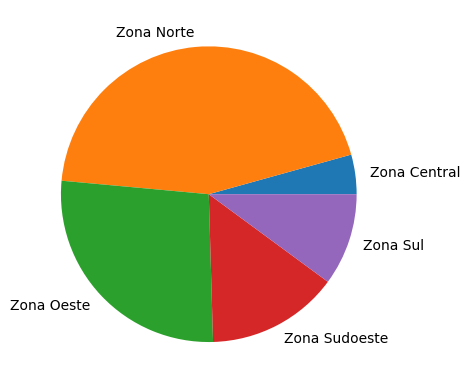

In [31]:
# A proporção populacional em 2022
pop_rio_2022 = df[(df['mes'] == 7) & (df['ano'] == 2022)].groupby(['ano','Zona'], as_index=False).pop.sum()
plt.pie(pop_rio_2022['pop'], labels = pop_rio_2022['Zona'])

Obs: A Zona Sudoeste foi sancionada apenas em setembro 2025. Antes disso, seus bairros faziam parte da zona oeste.

## Categorizando crimes
Há dezenas de colunas registrando crimes muito específicos. Sendo assim, nos será muito útil agrupar crimes em categorias, com a contagem somada de suas ocorrências.

Por ora, manteremos os dados mais granulares intactos, e apenas adicionaremos novas colunas com suas somas.

In [32]:
# Grupo: crimes violentos
df['violentos'] = df['hom_doloso'] + df['lesao_corp_morte'] + df['latrocinio'] + df['cvli'] + df['hom_por_interv_policial'] + df['letalidade_violenta'] + df['tentat_hom'] + df['lesao_corp_dolosa'] + df['estupro'] # Feminicido sumiu?

# Grupo: crimes de transito
df['transito'] = df['hom_culposo'] + df['lesao_corp_culposa']

# Grupo: roubos
df['roubos'] = df[['roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'roubo_cx_eletronico', 'roubo_bicicleta', 'outros_roubos']].sum(axis=1, skipna=True)
# Já existe uma coluna com o total de roubos, mas vamos primeiro verificar sua veracidade
if (df['roubos'] == df['total_roubos']).all():
    print("A soma dos roubos é igual ao total de roubos.")
else:
    print("A soma dos roubos NÃO é igual ao total de roubos.")
# Por algum motivo a coluna está em formato float, apesar de ser uma contagem de números inteiros. Corrigindo isso:
df['roubos'] = df['roubos'].fillna(0).astype(int)

# Grupo: furtos
# Já existe uma coluna com o total de furtos, mas vamos primeiro verificar sua veracidade
df['furtos'] = df[['furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'outros_furtos']].sum(axis=1, skipna=True)
if (df['furtos'] == df['total_furtos']).all():
    print("A soma dos furtos é igual ao total de furtos.")
else:
    print("A soma dos furtos NÃO é igual ao total de furtos.")

# Grupo: outros crimes
df['outros'] = df['sequestro'] + df['extorsao'] + df['sequestro_relampago'] + df['estelionato']

# Não irei considerar atividade policial e outras colunas não referentes a crimes

A soma dos roubos NÃO é igual ao total de roubos.
A soma dos furtos NÃO é igual ao total de furtos.


In [33]:
# Removendo as colunas 'total' que parecem ter somas incorretas
df = df.drop(columns=['total_roubos', 'total_furtos'])

## Valores Faltantes


In [34]:
# Checando onde ainda estão no dataset
df.isna().sum()[df.isna().sum() > 0]

,0
feminicidio,10480
tentativa_feminicidio,10480
roubo_bicicleta,5191
furto_bicicleta,5191
posse_drogas,1401
trafico_drogas,1401
apreensao_drogas_sem_autor,1401
apf,1401
aaapai,1401
cmp,1401


Por que tantos valores faltantes? A minha primeira hipótese é que começaram a ser registrados bem tarde no período que investigamos.

Vejamos onde os dados começam a aparecer:

In [35]:
# Feminicidio
# "Dado que não sejam NAs, sortear os registros de maneira ascendente no tempo"
df.loc[df['feminicidio'].notna(), ['mes_ano', 'feminicidio']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,feminicidio
10480,2024m10,0.0
10503,2024m10,0.0
10504,2024m10,0.0
10505,2024m10,0.0
10506,2024m10,0.0


In [36]:
# roubo_bicicleta
df.loc[df['roubo_bicicleta'].notna() , ['mes_ano', 'roubo_bicicleta']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,roubo_bicicleta
5191,2014m01,0.0
5214,2014m01,0.0
5215,2014m01,0.0
5216,2014m01,0.0
5217,2014m01,0.0


In [37]:
# furto_bicicleta
df.loc[df['furto_bicicleta'].notna(), ['mes_ano', 'furto_bicicleta']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,furto_bicicleta
5191,2014m01,0.0
5214,2014m01,0.0
5215,2014m01,0.0
5216,2014m01,0.0
5217,2014m01,0.0


In [38]:
# posse_drogas
df.loc[df['posse_drogas'].notna(), ['mes_ano', 'posse_drogas']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,posse_drogas
1401,2006m01,3.0
1423,2006m01,4.0
1424,2006m01,1.0
1425,2006m01,1.0
1426,2006m01,1.0


In [39]:
# posse_drogas - fim do período sem registros
df.loc[df['posse_drogas'].isna(), ['mes_ano', 'posse_drogas']].sort_values(by='mes_ano', ascending=False).head(5)

,mes_ano,posse_drogas
1400,2005m12,NaN
1381,2005m12,NaN
1379,2005m12,NaN
1378,2005m12,NaN
1377,2005m12,NaN


In [40]:
# trafico_drogas
df.loc[df['trafico_drogas'].notna(), ['mes_ano', 'trafico_drogas']].sort_values(by='mes_ano', ascending=True).head(5)

,mes_ano,trafico_drogas
1401,2006m01,0.0
1423,2006m01,3.0
1424,2006m01,2.0
1425,2006m01,6.0
1426,2006m01,0.0


* **feminicidio e tentativa_feminicio** simplesmente não servem para uma série histórica, visto que a contagem começa apenas em 2024.
* **roubo_bicicleta e furto_bicicleta** se encontram numa situação similar, começando a serem registrados apenas em 2014.
* **posse_drogas e trafico_drogas** demonstram uma contagem significativamente menor de NAs porque só perderam os primeiros anos do dataset, havendo começado os registros em 2006.
* **pop** (população), como visto antes, não passa de 2022.

In [41]:
# Deletar colunas
df = df.drop(columns=['feminicidio','tentativa_feminicidio','roubo_bicicleta','furto_bicicleta'])
df.head(5)

,cisp,mes,ano,mes_ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,...,fase,Unidade Territorial,Município,Zona,pop,violentos,transito,roubos,furtos,outros
0,1,1,2003,2003m01,5,1,3304557,0,0,0,...,3,Centro (parte),Rio de Janeiro,Zona Central,1551,41,16,100,169,70
1,4,1,2003,2003m01,5,1,3304557,3,0,0,...,3,"Centro (parte), Gamboa, Santo Cristo e Saúde",Rio de Janeiro,Zona Central,29903,57,39,83,115,2
2,5,1,2003,2003m01,5,1,3304557,3,0,0,...,3,"Centro (parte), Lapa e Paquetá",Rio de Janeiro,Zona Central,35792,85,20,123,216,37
3,6,1,2003,2003m01,1,1,3304557,6,0,0,...,3,CISP 6 (AISP 4),NaN,Zona Central,76561,65,21,143,90,8
4,7,1,2003,2003m01,1,1,3304557,4,0,0,...,3,CISP 7 (AISP 5),NaN,Zona Central,38806,34,2,55,35,4


## Normalização e Padronização

Com o dataset de segurança pública e o dataset de população limpos e em mãos, podemos finalmente analisar os dados adequadamente, de forma conduzente à interpretação dos insights.

Por que foi necessário complementar com dados populacionais o dataset de segurança pública? Pois isso nos permite investigar a criminalidade **relativa** à população.

A padronização típica no estudo da criminalidade é avaliar o crime per capita no modelo *"X ocorrências por 100 mil habitantes"*. Este é um tipo de **padronização substantiva**. Para que serve? P*ara tornar comparáveis unidades de tamanhos diferentes* - como por exemplo conglomerados de bairros, que muito podem diferir em população. Sem essa relação, esse contexto, pouco significa dizer que num dado local houveram 62 crimes de furto de celular num mês - pode ser muito ou pode ser pouco, dependendo da quantidade de pessoas que moram neste local!

Vamos então criar novos índices para isso adiante no projeto. Na seção média e mediana são contruídas colunas no formato "X ocorrências por 100 mil habitantes", baseadas nas colunas que categorizamos a pouco. Já na seção 'gráfico de linhas' a abordagem é diferente, e criamos índices base 100, pois nosso intuito passa a ser investigar apenas o desenvolvimento do crime ao longo do tempo. Por exemplo, uma taxa de roubos de 210 num dado ano não é interpretável por si só, isto é, não nos diz muito sobre a criminalidade absoluta, porém, em relação ao índice base 100 (com a base sendo 2003) nos permite entender que os roubos mais que dobraram no período.

<br>

---

<br>

E a normalização e padronização matemáticas? Possuem um lugar neste projeto?

A aplicação de normalização matemática (como min–max scaling) não é necessária porque as variáveis já foram colocadas em uma escala *substantivamente comparável* por meio da transformação em taxas (por exemplo, homicídios por 100 mil habitantes) e índices base 100. Essa padronização resolve o problema central — tornar observações de diferentes populações e períodos diretamente comparáveis — sem distorcer a interpretação dos valores.

Sem um leque de variáveis qualitativas para servirem de explicação, o foco está na dinâmica temporal da própria série (isto é, como o valor presente se relaciona com seus valores passados), e não na comparação entre variáveis com escalas arbitrárias - o que nos leva ao caminho da **autoregressão**. Aplicar min–max nesse contexto apenas reescalaria os dados para um intervalo artificial (0–1), sem agregar informação relevante e ainda prejudicando a leitura substantiva dos resultados (por exemplo, perder o significado de “X crimes por 100 mil habitantes”). Portanto, a padronização substantiva já cumpre o papel necessário, enquanto a normalização matemática seria redundante e potencialmente contraproducente.

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de segurança pública do Rio de Janeiro, visamos entender a distribuição, as relações e as características das variáveis, tanto para obtermos insights diretamente, por tabelas e visualizações, quanto para complementar as etapas subsequentes de pré-processamento e regressão.

Visto que este é um dataset complexo, será necessário eventualmente limitar a sua extensa granularidade. Por ora, podemos ainda investigá-lo do jeito que é.

## Total e Tipo das Instâncias

Após passar por nosso preparo preliminar, o dataset possui 11177 instâncias (observações) e 66 colunas - volume considerável. Visto que a a maioria das colunas representam contagens de registros, devem ser de tipo integer (número inteiro), mas temos algumas instâncias de floats presentes que devem ser investigadas adiante.

In [42]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 11177

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11177 entries, 0 to 11176
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        11177 non-null  int64  
 1   mes                         11177 non-null  int64  
 2   ano                         11177 non-null  int64  
 3   mes_ano                     11177 non-null  object 
 4   aisp                        11177 non-null  int64  
 5   risp                        11177 non-null  int64  
 6   mcirc                       11177 non-null  int64  
 7   hom_doloso                  11177 non-null  int64  
 8   lesao_corp_morte            11177 non-null  int64  
 9   latrocinio                  11177 non-null  int64  
 10  cvli                        11177 non-null  int64  
 11  hom_por_interv_policial     11177 non-null  int64  
 12  letalidade_violenta         11177

Devido à extensão do dataset, é impossível retratá-lo num gráfico só sem antes agregar features como tipos de registros ou zonas.

A seguir estudaremos as estatísticas descritivas para depois agregarmos o dataset.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis. Aqui seleciono as categorias que separamos antes, para facilidade de leitura.

In [43]:
# Estatísticas descritivas básicas do dataset
# Considere que cada linha representa um registro *mensal* numa dada *unidade territorial*
df.loc[:,['violentos', 'transito', 'roubos', 'furtos', 'outros']].describe()

,violentos,transito,roubos,furtos,outros
count,11177.000000,11177.000000,11177.000000,11177.000000,11177.000000
mean,75.196206,33.830098,162.755301,186.377829,58.460678
std,60.764670,27.804178,108.241342,130.598119,66.824873
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,16.000000,87.000000,98.000000,18.000000
50%,59.000000,27.000000,143.000000,158.000000,37.000000
75%,90.000000,43.000000,214.000000,241.000000,74.000000
max,469.000000,268.000000,906.000000,1660.000000,744.000000


### Média e Mediana

A **média** é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

A **mediana** é o valor central que divide um conjunto de dados ordenados (crescente ou decrescente) em duas metades iguais.  É mais robusta a valores extremos (outliers) do que a média, portanto pode dar uma ideia melhor de um valor típico porque não é tão distorcida por valores extremamente altos ou baixos.

Mas média e mediana do que?

É típico no estudo da criminalidade usar taxas de "*crimes por 100.000 habitantes*"; Ex: "Quantos crimes ocorreriam nesta zona se tivesse exatamente 100.000 habitantes?"

Utilizando este valor relativo, torna-se possível comparar a criminalidade regiões com populações de tamanhos distintos. Caso contrário, arrisca-se minimizar o crime em locais de baixa população ("apenas" dois homicídios no mesmo mês dentro de um prédio residencial já seria um absurdo) e exagerar a significância da contagem em locais com alta população (cem homicídios por mês no Brasil como um todo já seria um excelente avanço na segurança pública nacional).

Naturalmente, não estamos comparando residências com países, e sim unidades territoriais com diferentes níveis de densidade populacional!

Fórmula:
   taxa = (total de crimes / população) × 100.000

In [44]:
# Média e mediana *mensais* de crimes por unidade territorial, agregando o município como um todo.
# "Num mês típico, numa unidade territorial típica do Rio, quantos crimes por 100 mil habitantes ocorreram em cada categoria?"

crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_taxa = df.copy()
for col in crime_cols:
    df_taxa[f'{col}_100k'] = (df_taxa[col] / df_taxa['pop'] * 100_000).round(2)   # Tornando nossa contagem 'per capita' e em seguida multiplicando para tornar 'per 100mil'

cols_100k = [f'{col}_100k' for col in crime_cols]

df_taxa.groupby('Município')[cols_100k].agg(['mean', 'median']).round(2)

violentos_100k        transito_100k        roubos_100k          \
                         mean median          mean median        mean  median   
Município                                                                       
Rio de Janeiro          86.84  45.02         48.68  20.32      307.87  107.18   

               furtos_100k        outros_100k         
                      mean median        mean median  
Município                                             
Rio de Janeiro      584.43  94.24      208.28  22.32

Antes de partir para a comparação entre zonas e dos diferentes momentos no tempo, temos aqui uma visão agregada das categorias de crimes no Rio de Janeiro. As medidas de média e mediana se referem então à variação das contagens de ocorrências ao longo do período registrado.

Pode ser difícil de contemplar, por conta do quão abstrata esta agregação de dimensões é. Sendo assim, inevitavelmente teremos que investigar os dados de maneira mais granular!



---



In [45]:
# Vamos testar nosso dataset com uma pergunta particular:

# "Qual a taxa de crimes violentos por 100 mil habitante no CISP 1 (Centro (parte))? Como progride no tempo?"
df_taxa[(df_taxa['cisp'] == 1) & (df_taxa['ano']< 2023)][['cisp','mes_ano','Unidade Territorial','Zona','pop','violentos','violentos_100k']]

,cisp,mes_ano,Unidade Territorial,Zona,pop,violentos,violentos_100k
0,1,2003m01,Centro (parte),Zona Central,1551,41,2643.46
38,1,2003m02,Centro (parte),Zona Central,1551,37,2385.56
76,1,2003m03,Centro (parte),Zona Central,1551,30,1934.24
114,1,2003m04,Centro (parte),Zona Central,1551,25,1611.86
153,1,2003m05,Centro (parte),Zona Central,1551,26,1676.34
...,...,...,...,...,...,...,...
9414,1,2022m08,Centro (parte),Zona Central,1773,9,507.61
9455,1,2022m09,Centro (parte),Zona Central,1773,7,394.81
9496,1,2022m10,Centro (parte),Zona Central,1773,17,958.83
9537,1,2022m11,Centro (parte),Zona Central,1773,18,1015.23


Temos que em janeiro de 2003 a CISP 1 teve uma taxa altíssima de aproximadamente 2643 crimes violentos por 100 mil habitantes. Note que isso ocorre em grande parte por conta de quão depopulada a região é, com apenas 1551 habitantes na época.

Inspecionando qual região exatamente a CISP 1 corresponde a, encontramos que é a região portuária do Rio de Janeiro, uma região antes dedicada ao transporte de bens que caiu em desuso e abandono, com apenas recentes esforços em revitalizá-la como o 'Porto Maravilha'.

Esse entendimento parece consistente com os dados!



---



Vamos começar a agregar os dados por zona, ao invés de olhar pra cidade como um todo.

In [46]:
# Agrupando por Zona:

# Média e mediana mensais dos registros de crimes por zona:
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_zona = df.copy()
for col in crime_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in crime_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

violentos_100k        transito_100k        roubos_100k          \
                        mean median          mean median        mean  median   
Zona                                                                           
Zona Central          308.74  96.59        192.25  53.74     1302.18  274.31   
Zona Norte             45.53  43.15          20.7  19.24      146.17  136.17   
Zona Oeste             52.42  51.64         20.43  20.09       59.66   51.55   
Zona Sudoeste          48.01  46.76          23.6   21.3       74.51   68.62   
Zona Sul               36.58  34.58         17.82  16.94       80.53   80.86   

              furtos_100k         outros_100k         
                     mean  median        mean median  
Zona                                                  
Zona Central      2918.08  282.64     1095.27  38.91  
Zona Norte         101.52   81.97       23.86  16.82  
Zona Oeste          51.53   49.75       14.76  11.85  
Zona Sudoeste      117.12   87.78        34.7  24.69  
Zona Sul           231.46   224.7       47.85  40.44

Note: estas são a média e mediana do período de 23 anos como um todo! Precisamos de outro tipo de representação gráfica para capturar a tendência no tempo *E* por zona.


Temos um claro padrão de a média das ocorrências ser maior do que a mediana (especialmente na zona central), o que nos leva a um única conclusão:

=> O conjunto de dados é *enviesado para a direita*!

Isto é, a maioria dos registros são relativamente baixos (em relação à amplitude de sua distribuição), mas há locais e/ou momentos em que as diversas variedades de crimes atingem ***proporções extremas e atípicas*** que puxam a média para cima. Em outras palavras, o crime no Rio de Janeiro está longe de ser invariável nas escalas temporal e espacial, e esta variação parece ocorrer no sentido de ***aumento da criminalidade***, e raramente no sentido de uma redução atípica.



---

<br>

Vamos então esquecer as zonas por um momento e agrupar por ano.

In [47]:
# Agrupando por ano:

# Média e mediana mensais dos crimes dentro de uma unidade territorial *por ano* na cidade do Rio de Janeiro como um todo
# Isto é, a criminalidade num mês típico de cada um dos anos no dataset
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_zona = df.copy()
for col in crime_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in crime_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

violentos_100k        transito_100k        roubos_100k          \
               mean median          mean median        mean  median   
ano                                                                   
2003         123.75  55.13         62.47  24.31      311.96  132.43   
2004         118.11  53.29         62.33  23.88      275.88  117.24   
2005         104.24  54.64         49.58  22.08      295.68  116.13   
2006         104.72  50.42         53.76   20.2      323.05  128.32   
2007         107.97   48.9         62.93  22.12      411.81  131.77   
2008          99.75  46.58         70.48  23.93      407.57   134.1   
2009         108.21  51.25          53.1  23.29      419.01   119.3   
2010         107.34  48.87         66.87  24.64      320.52   98.64   
2011         106.82   51.4          85.6  26.94      249.18    80.1   
2012          99.73  54.63         74.47  26.48      205.65   74.28   
2013          87.81  53.24         52.48   27.7      234.09   88.12   
2014          75.45  52.99         41.27  26.18      227.31  108.77   
2015          66.05  47.58         35.71  23.78      228.68  104.16   
2016          69.53  45.11          33.4  20.07      268.05  136.12   
2017          64.18  41.92          28.1  16.13      315.52  165.66   
2018           61.0   40.5         28.55  15.36      356.84  157.79   
2019          61.09  38.98         25.88  14.85      326.12  128.36   
2020          43.83  28.66         13.21   9.27      223.61   76.44   
2021          44.35  28.51         15.16    9.8      192.68   76.41   
2022          49.35  32.03         16.11  10.75      216.32   78.16   
2023           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2024           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2025           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   
2026           <NA>   <NA>          <NA>   <NA>        <NA>    <NA>   

     furtos_100k         outros_100k         
            mean  median        mean median  
ano                                          
2003      467.52   74.65      132.23   7.71  
2004      507.98   76.72      121.05   8.86  
2005      552.38   77.54      139.33  11.44  
2006      616.85   79.56      191.13  12.17  
2007      685.69   88.34      296.27  14.22  
2008      726.39  102.68      210.13  15.64  
2009      732.35  102.47      237.52   13.1  
2010      752.73  101.07      246.71   14.7  
2011       687.7  103.07      239.71  19.12  
2012      657.45   105.1      233.82  21.44  
2013       546.0  103.68       204.0  24.05  
2014      492.72   96.63      122.66  23.54  
2015      456.84   89.48      161.06  23.47  
2016      472.32   91.84      115.26  24.84  
2017      413.28    94.5      127.78  20.56  
2018      442.65   81.31      137.96  22.73  
2019      524.11   91.34       180.6  25.74  
2020      303.87   70.82      194.29  31.62  
2021      262.34   71.04      233.72  44.83  
2022      530.65  100.24      244.44  73.41  
2023        <NA>    <NA>        <NA>   <NA>  
2024        <NA>    <NA>        <NA>   <NA>  
2025        <NA>    <NA>        <NA>   <NA>  
2026        <NA>    <NA>        <NA>   <NA>

Encontraremos mais insights quando olharmos para as visualizações, sem falar que aqui não enxergamos as diferenças entre zonas, mas mesmo nesta tabela já podemos perceber que:
* Há uma queda das taxas de crimes **violentos**, de **trânsito** e **roubos** no Rio de Janeiro.
* A categoria **furtos** parece ser de longe a mais errática, sem uma clareza de tendência (será melhor compreendida quando criarmos visualizações)
* Há uma ascensão dos **"outros crimes"** - o que nos convida a investigar *quais* especificamente que puxam esta média.



---






In [48]:
# Por curiosidade
# Quais as unidades territoriais com mais crimes em 2025?
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

crimes_ut_ano = (
    df.groupby(['ano','Zona','Unidade Territorial'])[crime_cols]
    .sum()
    .reset_index()
)
# Criando total de crimes
crimes_ut_ano['total_crimes'] = crimes_ut_ano[crime_cols].sum(axis=1)


crimes_ut_ano[crimes_ut_ano['ano'] == 2025].loc[:,['Zona','Unidade Territorial','total_crimes']].sort_values(by = 'total_crimes', ascending = False).head(5)

,Zona,Unidade Territorial,total_crimes
926,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",17172
927,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",16193
922,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",15986
901,Zona Central,"Centro (parte), Lapa e Paquetá",12112
914,Zona Norte,"Cavalcanti, Engenheiro Leal, Madureira, Turiaç...",10983


<br>

---
<br>

Vamos agora tornar nosso olhar ainda mais granular ao investigar os diferentes tipos de crime dentro de cada uma das 5 categorias.

### Crimes Violentos

In [49]:
# Violentos:
# Por zona, a média e mediana mensais de cada tipo de crime violento

violentos_cols = ['hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','letalidade_violenta','tentat_hom','lesao_corp_dolosa','estupro','violentos']

df_zona = df.copy()
for col in violentos_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in violentos_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

hom_doloso_100k        lesao_corp_morte_100k         \
                         mean median                  mean median   
Zona                                                                
Zona Central             6.24    2.4                   0.2    0.0   
Zona Norte               2.29   1.65                  0.03    0.0   
Zona Oeste               2.64    2.2                  0.02    0.0   
Zona Sudoeste            1.45   1.18                  0.02    0.0   
Zona Sul                 0.58    0.0                  0.02    0.0   

              latrocinio_100k        cvli_100k         \
                         mean median      mean median   
Zona                                                    
Zona Central             0.86    0.0      7.31   2.46   
Zona Norte               0.14    0.0      2.46   1.77   
Zona Oeste               0.06    0.0      2.72   2.23   
Zona Sudoeste            0.06    0.0      1.52   1.31   
Zona Sul                 0.04    0.0      0.64    0.0   

              hom_por_interv_policial_100k        letalidade_violenta_100k  \
                                      mean median                     mean   
Zona                                                                         
Zona Central                          1.25    0.0                     8.56   
Zona Norte                            0.97   0.52                     3.43   
Zona Oeste                            0.45    0.0                     3.18   
Zona Sudoeste                         0.25    0.0                     1.77   
Zona Sul                              0.26    0.0                      0.9   

                     tentat_hom_100k        lesao_corp_dolosa_100k         \
              median            mean median                   mean median   
Zona                                                                        
Zona Central    2.71           10.28   3.14                 265.68  68.78   
Zona Norte      2.58            2.36    1.6                  32.34  30.88   
Zona Oeste      2.77            1.63   1.27                   39.1  39.15   
Zona Sudoeste   1.45            1.61   1.16                  39.26  37.47   
Zona Sul         0.0            2.03    0.9                   30.9  29.21   

              estupro_100k        violentos_100k         
                      mean median           mean median  
Zona                                                     
Zona Central          8.35   2.44         308.74  96.59  
Zona Norte            1.52   1.31          45.53  43.15  
Zona Oeste            2.61   2.39          52.42  51.64  
Zona Sudoeste         2.09   1.86          48.01  46.76  
Zona Sul              1.21   1.03          36.58  34.58

In [50]:
# Violentos 2:
# Por ano, a média e mediana mensais de cada crimes violento na cidade como um todo

df_zona = df.copy()
for col in violentos_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in violentos_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

hom_doloso_100k        lesao_corp_morte_100k        latrocinio_100k  \
                mean median                  mean median            mean   
ano                                                                        
2003            3.75   2.57                  0.04    0.0            0.17   
2004            4.57   2.68                  0.04    0.0            0.43   
2005            4.06   2.73                  0.06    0.0            0.54   
2006            3.58   2.58                  0.04    0.0            0.33   
2007            4.45   2.38                  0.05    0.0            0.54   
2008            3.37   1.92                  0.06    0.0            0.43   
2009            4.29   2.12                  0.03    0.0            0.27   
2010            2.66   1.44                  0.04    0.0            0.09   
2011            2.18   1.14                  0.16    0.0             0.2   
2012            2.05   1.08                  0.02    0.0            0.06   
2013            1.85   1.22                  0.03    0.0            0.19   
2014            1.78    1.1                  0.14    0.0            0.08   
2015            1.61   1.11                  0.02    0.0            0.06   
2016            1.73    1.2                  0.04    0.0            0.26   
2017            2.04   1.49                  0.02    0.0            0.13   
2018            1.89   1.35                  0.05    0.0            0.09   
2019             1.7   1.15                  0.03    0.0            0.17   
2020            1.86   0.86                  0.02    0.0            0.04   
2021            0.91   0.71                  0.14    0.0            0.16   
2022            1.18   0.72                  0.01    0.0            0.05   
2023            <NA>   <NA>                  <NA>   <NA>            <NA>   
2024            <NA>   <NA>                  <NA>   <NA>            <NA>   
2025            <NA>   <NA>                  <NA>   <NA>            <NA>   
2026            <NA>   <NA>                  <NA>   <NA>            <NA>   

            cvli_100k        hom_por_interv_policial_100k         \
     median      mean median                         mean median   
ano                                                                
2003    0.0      3.96   2.63                         1.19   0.49   
2004    0.0      5.04   2.88                         1.14   0.26   
2005    0.0      4.66   2.91                         1.18   0.28   
2006    0.0      3.95   2.88                         0.93   0.33   
2007    0.0      5.04   2.55                         1.66   0.55   
2008    0.0      3.86   2.24                         0.94    0.0   
2009    0.0      4.59    2.2                         1.22    0.0   
2010    0.0      2.78   1.55                          0.6    0.0   
2011    0.0      2.54   1.24                         0.33    0.0   
2012    0.0      2.14   1.15                         0.35    0.0   
2013    0.0      2.07   1.33                         0.27    0.0   
2014    0.0       2.0   1.14                          0.3    0.0   
2015    0.0       1.7   1.19                          0.4    0.0   
2016    0.0      2.02   1.38                          0.7    0.0   
2017    0.0       2.2    1.6                         0.74    0.0   
2018    0.0      2.03   1.38                         0.73    0.0   
2019    0.0      1.89   1.19                         0.91    0.0   
2020    0.0      1.92   0.88                         0.48    0.0   
2021    0.0      1.21   0.75                         0.57    0.0   
2022    0.0      1.24    0.8                         0.49    0.0   
2023   <NA>      <NA>   <NA>                         <NA>   <NA>   
2024   <NA>      <NA>   <NA>                         <NA>   <NA>   
2025   <NA>      <NA>   <NA>                         <NA>   <NA>   
2026   <NA>      <NA>   <NA>                         <NA>   <NA>   

     letalidade_violenta_100k        tentat_hom_100k         \
                         mean median            mean

Por zona:
* Homicídio doloso e crimes violentos letais intencionais (cvli) demonstram significante variabilidade entre zonas, com a maior diferença sendo entre a Zona Central (max) e Zona Sul (min).
* Lesão corporal dolosa, sendo um crime muito mais frequente, parece acompanhar o padrão regional dos homicídios.

Por ano:
* Homicídio doloso - assim como a maioria dos outros crimes violentos - possui uma média e mediana relativamente baixa quando contrastadas aos outros crimes deste dataset. O pico é cedo, em 2004.
* Lesão corporal dolosa, isto é, o crime de ferir o outro, é distintamente mais frequente que todos os outros juntos. Enquanto sua média despencou, sua mediana foi reduzida de maneira mais moderada, indicando uma queda dos valores extremamente altos em particular.





---

<br>

Vamos aumentar a granularidade do projeto olhando para as unidades territoriais dentro das zonas. Mas apenas as com os maiores índices de criminalidade - já vimos que os dados são enviesados para a direita, o que sugere que encontraremos unidades territoriais com valores particularmente altos.

In [51]:
# Violentos 3

# Zona Central em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Central")]
    .groupby(["Zona","Unidade Territorial"])["violentos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['violentos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='violentos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['violentos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,violentos_100k,média_zona,diferença_percent
2,Zona Central,Centro (parte),625.12,153.03,308.49
4,Zona Central,"Centro (parte), Lapa e Paquetá",103.29,153.03,-32.51
3,Zona Central,"Centro (parte), Gamboa, Santo Cristo e Saúde",71.94,153.03,-52.99
1,Zona Central,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",46.76,153.03,-69.44
0,Zona Central,"Caju, Mangueira, São Cristóvão e Vasco da Gama",42.9,153.03,-71.97


In [52]:
# @title
# Zona Sudoeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sudoeste")]
    .groupby(["Zona","Unidade Territorial"])["violentos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['violentos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='violentos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['violentos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,violentos_100k,média_zona,diferença_percent
3,Zona Sudoeste,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",49.92,39.32,26.95
1,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",40.79,39.32,3.73
0,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",39.7,39.32,0.96
4,Zona Sudoeste,"Vila Valqueire, Praça Seca e Tanque (parte)",39.68,39.32,0.91
2,Zona Sudoeste,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",26.52,39.32,-32.56


In [53]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["violentos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['violentos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='violentos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['violentos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,violentos_100k,média_zona,diferença_percent
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",48.82,38.72,26.07
4,Zona Oeste,Paciência e Santa Cruz,40.08,38.72,3.5
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",36.93,38.72,-4.63
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",36.2,38.72,-6.52
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",31.58,38.72,-18.45


In [54]:
# @title
# Zona Norte em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Norte")]
    .groupby(["Zona","Unidade Territorial"])["violentos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['violentos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='violentos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['violentos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,violentos_100k,média_zona,diferença_percent
12,Zona Norte,"Coelho Neto, Colégio (parte), Honório Gurgel e...",37.84,30.37,24.61
7,Zona Norte,"Bento Ribeiro, Campinho, Marechal Hermes e Osw...",37.24,30.37,22.64
11,Zona Norte,"Cavalcanti, Engenheiro Leal, Madureira, Turiaç...",36.48,30.37,20.13
14,Zona Norte,"Del Castilho, Engenho da Rainha, Inhaúma, Mari...",35.07,30.37,15.49
16,Zona Norte,"Maracanã, Praça da Bandeira e Tijuca (parte)",34.41,30.37,13.32


In [55]:
# @title
# Zona Sul em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sul")]
    .groupby(["Zona","Unidade Territorial"])["violentos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['violentos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='violentos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['violentos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,violentos_100k,média_zona,diferença_percent
3,Zona Sul,Copacabana (parte) e Leme,34.63,24.04,44.04
2,Zona Sul,Copacabana (parte),26.02,24.04,8.23
0,Zona Sul,"Botafogo, Humaitá e Urca",25.62,24.04,6.57
4,Zona Sul,"Gávea, Jardim Botânico, Lagoa, São Conrado e V...",21.71,24.04,-9.7
1,Zona Sul,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",21.01,24.04,-12.61


Temos que:
* Na zona central, uma única unidade territorial arrasta a média consideravelmente pra cima. Consequentemente, toda outra registra valores muito abaixos da média.
* Na zona sul há um claro, mas não extremo, destaque para 'Copacabana (parte) e Leme'
* Nas outras zonas a diferença da unidade territorial líder não passa muito de 25% acima da média.

### Crimes de Trânsito

In [56]:
# Crimes de Trânsito:

# Por zona, a média e mediana mensais de cada crime de trânsito

transito_cols = ['hom_culposo','lesao_corp_culposa','transito']

df_zona = df.copy()
for col in transito_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in transito_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

hom_culposo_100k        lesao_corp_culposa_100k         \
                          mean median                    mean median   
Zona                                                                   
Zona Central               5.1    0.0                  187.15  50.76   
Zona Norte                0.81    0.6                   19.89  18.34   
Zona Oeste                0.95   0.82                   19.49  19.07   
Zona Sudoeste             0.81   0.67                    22.8  20.49   
Zona Sul                  0.62    0.0                    17.2   16.2   

              transito_100k         
                       mean median  
Zona                                
Zona Central         192.25  53.74  
Zona Norte             20.7  19.24  
Zona Oeste            20.43  20.09  
Zona Sudoeste          23.6   21.3  
Zona Sul              17.82  16.94

In [57]:
# Crimes de Trânsito 2:

# Por ano, a média e mediana mensais de cada crime de trânsito

df_zona = df.copy()
for col in transito_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in transito_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

hom_culposo_100k        lesao_corp_culposa_100k        transito_100k  \
                 mean median                    mean median          mean   
ano                                                                         
2003             1.95   0.77                   60.52  22.82         62.47   
2004             2.41   0.85                   59.92  22.62         62.33   
2005             1.92   0.93                   47.66  20.94         49.58   
2006             1.76   0.76                    52.0  19.01         53.76   
2007             1.89   0.98                   61.04  21.04         62.93   
2008             1.84   0.84                   68.64  22.93         70.48   
2009             1.19   0.55                   51.91  22.49          53.1   
2010             1.58   0.64                   65.29  23.76         66.87   
2011             1.98    0.7                   83.61  26.15          85.6   
2012             1.56   0.62                   72.91  25.86         74.47   
2013             0.95   0.56                   51.53  26.98         52.48   
2014             0.76   0.56                   40.51  26.02         41.27   
2015             0.81    0.0                    34.9  23.11         35.71   
2016             1.02   0.36                   32.37  19.66          33.4   
2017             1.27   0.55                   26.83  15.45          28.1   
2018             1.31   0.59                   27.24   14.7         28.55   
2019             1.35   0.53                   24.53  14.02         25.88   
2020             0.86   0.52                   12.35   8.56         13.21   
2021              1.5   0.44                   13.66   9.14         15.16   
2022             0.99   0.49                   15.12  10.11         16.11   
2023             <NA>   <NA>                    <NA>   <NA>          <NA>   
2024             <NA>   <NA>                    <NA>   <NA>          <NA>   
2025             <NA>   <NA>                    <NA>   <NA>          <NA>   
2026             <NA>   <NA>                    <NA>   <NA>          <NA>   

             
     median  
ano          
2003  24.31  
2004  23.88  
2005  22.08  
2006   20.2  
2007  22.12  
2008  23.93  
2009  23.29  
2010  24.64  
2011  26.94  
2012  26.48  
2013   27.7  
2014  26.18  
2015  23.78  
2016  20.07  
2017  16.13  
2018  15.36  
2019  14.85  
2020   9.27  
2021    9.8  
2022  10.75  
2023   <NA>  
2024   <NA>  
2025   <NA>  
2026   <NA>

Por zona:
* Os valores da Zona Central são significativamente maiores que os das outras zonas, além de apresentarem diferença considerável entre média e mediana, o que insinua a presença de outliers (a unidade territorial "Centro (parte)", provavelmente)
* As outras quatro zonas pouco divergem entre si nesta categoria.

Por ano:
* Homicídio culposo apresenta queda gradual ao longo do período.
* Lesão corporal culposa teve um pico prolongado no meio do período, em meados de 2011, mas esteve em baixa desde antes da pandemia (sem os dados populacionais de 2023 a 2026 é difícil avaliar o que é o novo normal e o que é efeito da pandemia nesses últimos anos.)



In [58]:
# Crimes de Trânsito 3

# Zona Central em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Central")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
2,Zona Central,Centro (parte),155.1,45.22,242.96
0,Zona Central,"Caju, Mangueira, São Cristóvão e Vasco da Gama",32.46,45.22,-28.22
3,Zona Central,"Centro (parte), Gamboa, Santo Cristo e Saúde",31.21,45.22,-30.99
4,Zona Central,"Centro (parte), Lapa e Paquetá",25.67,45.22,-43.24
1,Zona Central,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",22.76,45.22,-49.67


In [59]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",16.99,11.54,47.25
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",13.32,11.54,15.44
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",10.88,11.54,-5.71
4,Zona Oeste,Paciência e Santa Cruz,8.7,11.54,-24.6
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",7.8,11.54,-32.4


In [60]:
# @title
# Zona Sudoeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sudoeste")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
1,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",21.78,14.42,51.02
3,Zona Sudoeste,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",17.79,14.42,23.35
2,Zona Sudoeste,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",11.9,14.42,-17.49
0,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",10.58,14.42,-26.64
4,Zona Sudoeste,"Vila Valqueire, Praça Seca e Tanque (parte)",10.06,14.42,-30.25


In [61]:
# @title
# Zona Norte em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Norte")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
16,Zona Norte,"Maracanã, Praça da Bandeira e Tijuca (parte)",17.15,11.09,54.58
14,Zona Norte,"Del Castilho, Engenho da Rainha, Inhaúma, Mari...",17.05,11.09,53.68
6,Zona Norte,"Benfica, Bonsucesso, Higienópolis, Manguinhos,...",15.37,11.09,38.53
0,Zona Norte,"Abolição, Água Santa (parte), Encantado, Engen...",15.08,11.09,35.92
10,Zona Norte,"Cachambi, Méier (parte) e Todos os Santos (parte)",14.18,11.09,27.81


In [62]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",16.99,11.54,47.25
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",13.32,11.54,15.44
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",10.88,11.54,-5.71
4,Zona Oeste,Paciência e Santa Cruz,8.7,11.54,-24.6
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",7.8,11.54,-32.4


In [63]:
# @title
# Zona Sul em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sul")]
    .groupby(["Zona","Unidade Territorial"])["transito_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['transito_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='transito_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['transito_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,transito_100k,média_zona,diferença_percent
0,Zona Sul,"Botafogo, Humaitá e Urca",15.34,8.51,80.19
4,Zona Sul,"Gávea, Jardim Botânico, Lagoa, São Conrado e V...",10.42,8.51,22.4
1,Zona Sul,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",8.96,8.51,5.25
5,Zona Sul,Ipanema e Leblon,8.4,8.51,-1.33
3,Zona Sul,Copacabana (parte) e Leme,8.05,8.51,-5.44


Temos que:
* Novamente "Centro (parte)" tem destaque na zona central
* Todas as zonas tiverem ao menos uma forte líder, na casa dos 50% acima da média.
* Na zona sul o destaque da região "Botafogo, Humaitá e Urca" é ainda maior, com uma diferença de 80% em relação à média (dito isso, é a zona com as taxas mais baixas)

### Roubos

In [64]:
# Roubos:

# Por zona, a média e mediana mensais de cada tipo de roubo

roubo_cols = ['roubo_transeunte','roubo_celular','roubo_em_coletivo','roubo_veiculo','roubo_carga','roubo_comercio','roubo_residencia','roubo_banco','roubo_cx_eletronico','roubo_conducao_saque','roubo_apos_saque','roubo_cx_eletronico','outros_roubos','roubos']

df_zona = df.copy()
for col in roubo_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in roubo_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

roubo_transeunte_100k         roubo_celular_100k         \
                               mean  median               mean median   
Zona                                                                    
Zona Central                 719.88  111.26             178.81  26.06   
Zona Norte                     55.6   49.83              12.91   9.66   
Zona Oeste                    24.11    19.4               5.56   3.79   
Zona Sudoeste                 30.45   27.35               7.46   6.38   
Zona Sul                      35.97   33.09               9.72   8.06   

              roubo_em_coletivo_100k        roubo_veiculo_100k         \
                                mean median               mean median   
Zona                                                                    
Zona Central                   80.14  19.63              41.84  21.66   
Zona Norte                      8.83   6.22              36.35  31.06   
Zona Oeste                      3.58    3.2              15.04  11.94   
Zona Sudoeste                   4.93   4.28              15.25  11.07   
Zona Sul                         4.7   3.84               5.47   3.29   

              roubo_carga_100k         ... roubo_conducao_saque_100k         \
                          mean median  ...                      mean median   
Zona                                   ...                                    
Zona Central             37.94   4.59  ...                       4.5    0.0   
Zona Norte                5.52   3.42  ...                      0.11    0.0   
Zona Oeste                2.37   1.66  ...                      0.04    0.0   
Zona Sudoeste             1.05   0.74  ...                      0.17    0.0   
Zona Sul                  0.58    0.0  ...                      0.12    0.0   

              roubo_apos_saque_100k        roubo_cx_eletronico_100k         \
                               mean median                     mean median   
Zona                                                                         
Zona Central                  53.99   2.58                     1.41    0.0   
Zona Norte                     1.41   0.89                     0.03    0.0   
Zona Oeste                     0.72   0.52                     0.02    0.0   
Zona Sudoeste                  1.25   0.76                     0.03    0.0   
Zona Sul                       0.87    0.0                     0.04    0.0   

              outros_roubos_100k        roubos_100k          
                            mean median        mean  median  
Zona                                                         
Zona Central              125.53  39.38     1302.18  274.31  
Zona Norte                 20.41  14.99      146.17  136.17  
Zona Oeste                  5.82   4.28       59.66   51.55  
Zona Sudoeste               9.72   8.36       74.51   68.62  
Zona Sul                   17.06  13.46       80.53   80.86  

[5 rows x 28 columns]

In [65]:
# Roubos 2

# Por ano, a média e mediana mensais de cada crime de trânsito

df_zona = df.copy()
for col in roubo_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in roubo_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

roubo_transeunte_100k        roubo_celular_100k         \
                      mean median               mean median   
ano                                                           
2003                  72.8  16.22               64.0  13.23   
2004                 81.05  20.07              49.69   9.59   
2005                114.87  35.66              31.77   6.18   
2006                141.42  45.26              36.73   7.08   
2007                202.14  56.34              51.01   6.15   
2008                219.61   61.3              52.75   6.64   
2009                270.18   58.0              35.43   7.26   
2010                191.37  48.08              24.86   6.23   
2011                146.69  38.52              16.57   4.44   
2012                116.79  34.22              13.41   2.86   
2013                133.93  40.56              19.15   3.96   
2014                131.59  56.11              17.41   6.06   
2015                121.32  49.14              23.81   9.09   
2016                132.39  58.42              31.25  12.18   
2017                143.72  58.24              43.62  17.78   
2018                175.26   54.2              52.98  18.77   
2019                163.65  49.25              53.51  17.24   
2020                 122.8  28.26              34.66   9.99   
2021                101.21  29.94              29.73  10.54   
2022                 122.8  27.38              33.38  12.55   
2023                  <NA>   <NA>               <NA>   <NA>   
2024                  <NA>   <NA>               <NA>   <NA>   
2025                  <NA>   <NA>               <NA>   <NA>   
2026                  <NA>   <NA>               <NA>   <NA>   

     roubo_em_coletivo_100k        roubo_veiculo_100k        roubo_carga_100k  \
                       mean median               mean median             mean   
ano                                                                             
2003                  13.34   4.04              44.58  33.44             9.93   
2004                  10.45   4.14              42.79  36.17             8.58   
2005                  17.66   6.49              39.68  33.41            10.02   
2006                   22.1    7.6              40.95  37.81            14.39   
2007                  21.77   7.36              38.08  27.33            20.71   
2008                  22.69   7.18              30.27  23.99             10.2   
2009                  22.09   6.14              25.94  19.93             8.32   
2010                  19.83   5.56              18.13  14.53            17.09   
2011                  15.89   3.95              16.42  12.02             7.03   
2012                  10.34   2.87              16.85  12.58             5.42   
2013                  12.76   3.32              17.41  13.18             5.41   
2014                  12.48   4.39              19.21  12.99            10.38   
2015                  12.39   4.48              21.36  14.46             8.97   
2016                  17.83    6.0              29.61  20.94            10.19   
2017                  20.28   7.81              36.55  29.37             8.78   
2018                  23.03   7.22              35.23   24.7              5.6   
2019                  34.19   7.38              23.46  17.42             5.04   
2020                  16.38    4.1              14.92   11.4             3.02   
2021                  18.25   5.03              14.97  11.77             2.23   
2022                  10.96    3.5              18.34  14.63             3.18   
2023                   <NA>   <NA>               <NA>   <NA>             <NA>   
2024                   <NA>   <NA>               <NA>   <NA>             <NA>   
2025                   <NA>   <NA>               <NA>   <NA>             <NA>   
2026                   <NA>   <NA>               <NA>   <NA>             <NA>   

             ... roubo_conducao_saque_100k        roubo_apos_saque_100k  \
     median  ...                      me

Por zona:
* Zona central em evidente destaque parece ser um padrão duradouro neste dataset a este ponto...
* Desta vez há sim um claro segundo lugar, que é a zona norte. Surpreendentemente, a zona sul, que ao longo do dataset se destaca como uma das zonas de menor criminalidade, está em terceiro na categoria roubos.
* Já em crimes de roubo de veículos e de carga, a zona sul retorna ao último lugar. Essa dinâmica já parece pintar uma perspectiva sobre a incidência dos diferentes crimes no espaço da cidade.

Por ano:
* Roubo de transeuntes (ou assalto) parece ter tido picos em meados de 2009 e de 2018, mas estar em baixa atualmente no período pós-pandemico.
* Roubo de celular estranhamente não coincide com o nível de ocorrências do roubo de transeuntes, em geral tendo frequência bem mais baixa. Dito isso, seus picos coicidem com os do tipo anterior. Atualmente estão bem mais próximos do que na maior parte do período.
* Roubo em coletivo (ou arrastão) é mais estável, terminando numa taxa não muito diferente de quando começou em 2003, mas compartilha os picos e vales ao longo do caminho com os dois últimos tipos.
* Roubo de veículo tem seu auge nos primeiros anos do dataset, apenas com um outro pico em 2016-2018. Parece estar relativamente em baixa atualmente.
* "Outros roubos" teve uma queda considerável ao longo do período.

In [66]:
# Roubos 3

# Zona Central em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Central")]
    .groupby(["Zona","Unidade Territorial"])["roubos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['roubos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='roubos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['roubos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,roubos_100k,média_zona,diferença_percent
2,Zona Central,Centro (parte),4855.24,1011.05,380.22
4,Zona Central,"Centro (parte), Lapa e Paquetá",516.87,1011.05,-48.88
3,Zona Central,"Centro (parte), Gamboa, Santo Cristo e Saúde",335.29,1011.05,-66.84
0,Zona Central,"Caju, Mangueira, São Cristóvão e Vasco da Gama",163.86,1011.05,-83.79
1,Zona Central,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",98.29,1011.05,-90.28


In [67]:
# @title
# Zona Sudoeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sudoeste")]
    .groupby(["Zona","Unidade Territorial"])["roubos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['roubos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='roubos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['roubos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,roubos_100k,média_zona,diferença_percent
4,Zona Sudoeste,"Vila Valqueire, Praça Seca e Tanque (parte)",64.77,56.79,14.04
1,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",64.15,56.79,12.95
2,Zona Sudoeste,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",53.91,56.79,-5.08
3,Zona Sudoeste,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",50.76,56.79,-10.63
0,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",50.39,56.79,-11.28


In [68]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["roubos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['roubos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='roubos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['roubos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,roubos_100k,média_zona,diferença_percent
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",71.4,40.83,74.87
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",49.52,40.83,21.28
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",34.19,40.83,-16.26
4,Zona Oeste,Paciência e Santa Cruz,25.86,40.83,-36.66
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",23.19,40.83,-43.2


In [69]:
# @title
# Zona Norte em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Norte")]
    .groupby(["Zona","Unidade Territorial"])["roubos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['roubos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='roubos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['roubos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,roubos_100k,média_zona,diferença_percent
16,Zona Norte,"Maracanã, Praça da Bandeira e Tijuca (parte)",230.54,105.72,118.06
12,Zona Norte,"Coelho Neto, Colégio (parte), Honório Gurgel e...",157.69,105.72,49.16
11,Zona Norte,"Cavalcanti, Engenheiro Leal, Madureira, Turiaç...",149.38,105.72,41.3
14,Zona Norte,"Del Castilho, Engenho da Rainha, Inhaúma, Mari...",142.83,105.72,35.1
10,Zona Norte,"Cachambi, Méier (parte) e Todos os Santos (parte)",141.83,105.72,34.15


In [70]:
# @title
# Zona Sul em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sul")]
    .groupby(["Zona","Unidade Territorial"])["roubos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['roubos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='roubos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['roubos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,roubos_100k,média_zona,diferença_percent
1,Zona Sul,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",87.72,58.84,49.09
0,Zona Sul,"Botafogo, Humaitá e Urca",83.58,58.84,42.05
3,Zona Sul,Copacabana (parte) e Leme,82.42,58.84,40.08
5,Zona Sul,Ipanema e Leblon,66.61,58.84,13.21
2,Zona Sul,Copacabana (parte),49.93,58.84,-15.14


Temos que:
* "Centro(parte)" continua um outlier.
* Destaques consideráveis para "Campo dos Afonsos, Deodoro, Jardim Sulacap, Magalhães Bastos, Realengo e Vila Militar" na zona oeste (75% acima da média) e "Catete, Cosme Velho, Flamengo, Glória e Laranjeiras" na zona sul (49% acima da média)
* Mas a maior diferença é na zona norte, onde "Maracanã, Praça da Bandeira e Tijuca (parte)" possui mais que o dobro da média dos roubos na zona.

### Furtos

In [71]:
# Furtos:

# Por zona, a média e mediana mensais de cada tipo de furto

furto_cols = ['furto_veiculos','furto_transeunte','furto_coletivo','furto_celular','outros_furtos','furtos']

df_zona = df.copy()
for col in furto_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in furto_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

furto_veiculos_100k        furto_transeunte_100k         \
                             mean median                  mean median   
Zona                                                                    
Zona Central                 90.8  16.59                957.75  76.68   
Zona Norte                  12.18   9.84                 15.77   9.75   
Zona Oeste                   8.17   7.52                  6.88   5.86   
Zona Sudoeste               12.78   9.71                 11.49    9.1   
Zona Sul                    11.78   7.32                 52.69   37.7   

              furto_coletivo_100k        furto_celular_100k         \
                             mean median               mean median   
Zona                                                                 
Zona Central               135.77  23.14              535.0  46.46   
Zona Norte                   6.12    4.7              12.36    8.5   
Zona Oeste                   3.55   3.37               6.52   6.06   
Zona Sudoeste                9.01   7.26              18.85  12.19   
Zona Sul                     15.8  14.09              33.27  28.59   

              outros_furtos_100k         furtos_100k          
                            mean  median        mean  median  
Zona                                                          
Zona Central             1198.76  145.12     2918.08  282.64  
Zona Norte                 55.08   45.38      101.52   81.97  
Zona Oeste                  26.4   26.14       51.53   49.75  
Zona Sudoeste               65.0   50.42      117.12   87.78  
Zona Sul                  117.93  110.28      231.46   224.7

In [72]:
# Furtos 2:

# Por ano, a média e mediana mensais de cada tipo de furto na cidade

df_zona = df.copy()
for col in furto_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in furto_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

furto_veiculos_100k        furto_transeunte_100k         \
                    mean median                  mean median   
ano                                                            
2003               41.75  16.64                  90.4   5.14   
2004                47.5  14.08                110.22   4.88   
2005               46.66  14.36                106.21   7.06   
2006               32.24  15.08                136.66  10.09   
2007               26.93  12.98                183.48  11.12   
2008                38.7  13.83                172.16  14.33   
2009               38.71  12.22                268.45  15.29   
2010               28.19   9.86                274.76   14.2   
2011                20.9   7.29                271.29  17.08   
2012               18.79   8.88                253.24  17.46   
2013               15.41   8.86                 193.9  19.24   
2014               13.64   8.66                193.74  17.35   
2015               12.61   8.43                 167.2  16.56   
2016               12.31   8.02                164.34   13.1   
2017               12.76   7.88                 96.93  10.72   
2018               12.83   8.19                121.35  10.23   
2019                13.0   7.18                140.54    9.1   
2020               14.55   6.51                 72.07   4.73   
2021               10.65   7.21                 54.19   5.72   
2022               16.15   8.78                157.58   8.62   
2023                <NA>   <NA>                  <NA>   <NA>   
2024                <NA>   <NA>                  <NA>   <NA>   
2025                <NA>   <NA>                  <NA>   <NA>   
2026                <NA>   <NA>                  <NA>   <NA>   

     furto_coletivo_100k        furto_celular_100k        outros_furtos_100k  \
                    mean median               mean median               mean   
ano                                                                            
2003                1.53    0.0               80.9    4.4             252.94   
2004                7.67   1.09              96.34   6.07             246.26   
2005                15.6   3.82             117.01   9.31              266.9   
2006               19.05   4.73              144.9  13.11             283.99   
2007               28.27   5.72             142.43   12.2             304.59   
2008               31.79    6.8              144.2  15.33             339.56   
2009               37.08   7.95              106.7  16.12             281.41   
2010               44.01   7.95             125.35  16.85             280.42   
2011               43.74   7.52             104.14  16.38             247.63   
2012               38.88   7.65              83.98  12.87             262.56   
2013               33.13    7.8              76.78  11.12             226.78   
2014               31.53    7.9              56.12   9.68             197.69   
2015               30.51    7.5              69.82  10.32             176.69   
2016               28.39    8.1              73.69   9.93             193.58   
2017               24.34   5.82              61.14    9.3              218.1   
2018                31.3   7.34              72.22   8.08             204.95   
2019               30.07   7.84              86.83   9.62             253.67   
2020               14.33   3.12              59.93   5.63             142.99   
2021               18.66   4.88              45.81   8.09             133.04   
2022               31.04   7.95             140.65  15.92             185.24   
2023                <NA>   <NA>               <NA>   <NA>               <NA>   
2024                <NA>   <NA>               <NA>   <NA>               <NA>   
2025                <NA>   <NA>               <NA>   <NA>               <NA>   
2026                <NA>   <NA>               <NA>   <NA>               <NA>   

            furtos_100k          
     median        mean  median  
ano                              
2003  46.44  

Por zona:
* O destaque da criminalidade na zona central é mantido com a excessão do furto de veículos, onde é mais moderado, por algum motivo.
* Com a excessão (também) do furto de veículos, a zona sul é o claro segundo lugar em frequência de ocorrências de todos os outros tipos de furto. Haveria um 'perfil de crime' para a zona sul que é distinto do resto da cidade?

Por ano:
* **Furto de veículos** quase cai pela metade ao longo do período. Um tipo de crime saindo de moda?
* **Furto de transeuntes** possui médias consideravelmente mais alta que as medianas, sugerindo outliers extremos.
* **Furto em coletivo** parece disparar logo no começo do período e flutua por volta de uma mediana de  7,8 por 100 mil.
* **Furto de celular** acompanha o furto de transeuntes.
* **Outros furtos** (que não se encaixam nas categorias acima) tiveram um ligeiro aumento. Vale notar que sempre foram significantes comparados aos outros



In [73]:
# Furtos 3

# Zona Central em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Central")]
    .groupby(["Zona","Unidade Territorial"])["furtos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['furtos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='furtos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['furtos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,furtos_100k,média_zona,diferença_percent
2,Zona Central,Centro (parte),14626.81,2852.17,412.83
4,Zona Central,"Centro (parte), Lapa e Paquetá",1094.66,2852.17,-61.62
3,Zona Central,"Centro (parte), Gamboa, Santo Cristo e Saúde",825.19,2852.17,-71.07
0,Zona Central,"Caju, Mangueira, São Cristóvão e Vasco da Gama",269.49,2852.17,-90.55
1,Zona Central,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",204.2,2852.17,-92.84


In [74]:
# @title
# Zona Sudoeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sudoeste")]
    .groupby(["Zona","Unidade Territorial"])["furtos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['furtos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='furtos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['furtos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,furtos_100k,média_zona,diferença_percent
1,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",370.74,160.56,130.91
3,Zona Sudoeste,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",168.04,160.56,4.66
0,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",115.64,160.56,-27.98
4,Zona Sudoeste,"Vila Valqueire, Praça Seca e Tanque (parte)",84.26,160.56,-47.52
2,Zona Sudoeste,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",64.12,160.56,-60.06


In [75]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["furtos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['furtos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='furtos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['furtos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,furtos_100k,média_zona,diferença_percent
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",63.85,42.82,49.12
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",46.39,42.82,8.34
4,Zona Oeste,Paciência e Santa Cruz,36.24,42.82,-15.36
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",34.28,42.82,-19.94
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",33.32,42.82,-22.18


In [76]:
# @title
# Zona Norte em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Norte")]
    .groupby(["Zona","Unidade Territorial"])["furtos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['furtos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='furtos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['furtos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,furtos_100k,média_zona,diferença_percent
16,Zona Norte,"Maracanã, Praça da Bandeira e Tijuca (parte)",430.86,109.05,295.09
10,Zona Norte,"Cachambi, Méier (parte) e Todos os Santos (parte)",158.25,109.05,45.11
11,Zona Norte,"Cavalcanti, Engenheiro Leal, Madureira, Turiaç...",151.49,109.05,38.91
2,Zona Norte,Alto da Boa Vista e Tijuca (parte),135.93,109.05,24.65
15,Zona Norte,"Engenho Novo, Jacaré, Jacarezinho, Riachuelo, ...",108.42,109.05,-0.58


In [77]:
# @title
# Zona Sul em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sul")]
    .groupby(["Zona","Unidade Territorial"])["furtos_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['furtos_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='furtos_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['furtos_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,furtos_100k,média_zona,diferença_percent
3,Zona Sul,Copacabana (parte) e Leme,402.11,237.7,69.17
5,Zona Sul,Ipanema e Leblon,327.76,237.7,37.89
0,Zona Sul,"Botafogo, Humaitá e Urca",285.91,237.7,20.28
2,Zona Sul,Copacabana (parte),258.95,237.7,8.94
4,Zona Sul,"Gávea, Jardim Botânico, Lagoa, São Conrado e V...",188.5,237.7,-20.7


Temos que:
* "Centro(parte)" continua um outlier.
* "Maracanã, Praça da Bandeira e Tijuca (parte)" na zona norte e "Barra da Tijuca, Itanhangá, Joá" na zona sudoeste extremamente excedem as médias de suas zonas, com 295% e e 131% respectivamente.
* "Copacabana (parte) e Leme" excede a média da zona sul em 70%, mas as próximas unidades territoriais não estão muito atrás, sugerindo um outlier de baixa taxa de furtos.

### Outros Crimes Contra o Patrimônio

In [78]:
# Outros crimes:

# Por zona, a média e mediana mensais de cada um dos crimes classificados como 'outros crimes contra o patrimônio'
# "Extorsão mediante sequestro (sequestro clássico), Extorsão, Extorsão com momentânea privação da liberdade (sequestro relâmpago), Estelionato"

outros_cols = ['sequestro','extorsao','sequestro_relampago','estelionato','outros']

df_zona = df.copy()
for col in outros_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in outros_cols]

df_zona.groupby('Zona')[cols_100k].agg(['mean', 'median']).round(2)

sequestro_100k        extorsao_100k         \
                        mean median          mean median   
Zona                                                       
Zona Central            0.01    0.0         26.14   2.29   
Zona Norte               0.0    0.0          1.02   0.76   
Zona Oeste               0.0    0.0           0.6   0.53   
Zona Sudoeste            0.0    0.0          1.47   1.15   
Zona Sul                0.01    0.0          2.35   1.52   

              sequestro_relampago_100k        estelionato_100k         \
                                  mean median             mean median   
Zona                                                                    
Zona Central                      0.58    0.0          1068.53  37.32   
Zona Norte                        0.09    0.0            22.75   15.8   
Zona Oeste                        0.03    0.0            14.13  11.16   
Zona Sudoeste                     0.16    0.0            33.07  23.31   
Zona Sul                           0.1    0.0            45.38  37.26   

              outros_100k         
                     mean median  
Zona                              
Zona Central      1095.27  38.91  
Zona Norte          23.86  16.82  
Zona Oeste          14.76  11.85  
Zona Sudoeste        34.7  24.69  
Zona Sul            47.85  40.44

In [79]:
# Outros crimes 2:

# Por ano, a média e mediana mensais de cada um dos crimes classificados como 'outros crimes contra o patrimônio'

df_zona = df.copy()
for col in outros_cols:
    df_zona[f'{col}_100k'] = (df_zona[col] / df_zona['pop'] * 100_000).round(2)

cols_100k = [f'{col}_100k' for col in outros_cols]

df_zona.groupby('ano')[cols_100k].agg(['mean', 'median']).round(2)

sequestro_100k        extorsao_100k        sequestro_relampago_100k  \
               mean median          mean median                     mean   
ano                                                                        
2003            0.0    0.0          2.38    0.0                     0.01   
2004           0.01    0.0          2.89   0.69                     0.02   
2005            0.0    0.0          8.32   1.18                     0.29   
2006           0.01    0.0           7.2   1.08                     0.11   
2007            0.0    0.0          7.55   0.66                     0.16   
2008           0.01    0.0          6.99   1.08                     0.06   
2009            0.0    0.0          6.74   0.68                     0.07   
2010           0.01    0.0         10.14   0.77                     0.46   
2011           0.01    0.0         10.27   1.12                     0.23   
2012           0.01    0.0          6.84   0.89                     0.13   
2013            0.0    0.0          4.27   1.14                      0.1   
2014            0.0    0.0          2.56   0.93                     0.17   
2015            0.0    0.0          4.04   1.11                     0.12   
2016           0.02    0.0          1.91   0.87                     0.07   
2017            0.0    0.0          4.51   0.91                     0.12   
2018            0.0    0.0           3.0   0.89                     0.21   
2019            0.0    0.0          3.06    0.9                     0.23   
2020            0.0    0.0           1.7    0.6                      0.2   
2021            0.0    0.0          2.14   0.86                     0.17   
2022            0.0    0.0          4.01   1.33                     0.38   
2023           <NA>   <NA>          <NA>   <NA>                     <NA>   
2024           <NA>   <NA>          <NA>   <NA>                     <NA>   
2025           <NA>   <NA>          <NA>   <NA>                     <NA>   
2026           <NA>   <NA>          <NA>   <NA>                     <NA>   

            estelionato_100k        outros_100k         
     median             mean median        mean median  
ano                                                     
2003    0.0           129.84   6.74      132.23   7.71  
2004    0.0           118.13   7.87      121.05   8.86  
2005    0.0           130.71   9.82      139.33  11.44  
2006    0.0           183.81  10.66      191.13  12.17  
2007    0.0           288.57  13.48      296.27  14.22  
2008    0.0           203.07  14.08      210.13  15.64  
2009    0.0            230.7   12.3      237.52   13.1  
2010    0.0           236.11  13.62      246.71   14.7  
2011    0.0           229.21  17.61      239.71  19.12  
2012    0.0           226.84  20.63      233.82  21.44  
2013    0.0           199.63  22.76       204.0  24.05  
2014    0.0           119.93  22.32      122.66  23.54  
2015    0.0           156.89  21.82      161.06  23.47  
2016    0.0           113.27  23.54      115.26  24.84  
2017    0.0           123.15  19.41      127.78  20.56  
2018    0.0           134.75  21.94      137.96  22.73  
2019    0.0           177.31  24.44       180.6  25.74  
2020    0.0            192.4  30.39      194.29  31.62  
2021    0.0           231.41  43.83      233.72  44.83  
2022    0.0           240.05   72.0      244.44  73.41  
2023   <NA>             <NA>   <NA>        <NA>   <NA>  
2024   <NA>             <NA>   <NA>        <NA>   <NA>  
2025   <NA>             <NA>   <NA>        <NA>   <NA>  
2026   <NA>             <NA>   <NA>        <NA>   <NA>

Por zona:
* Novamente temos o padrão em que a Zona Sul e Sudoeste, as zonas mais ricas da cidade, curiosamente ficam em segundo e terceiro lugar. Uma característica deste tipo de crime?

Por ano:
* Não podia ser mais claro: a categoria "outros crimes" cresceu quase que exclusivamente pro conta da ascensão do **estelionato**, o crime de "obter para si ou para outrem vantagem ilícita em prejuízo alheio, induzindo ou mantendo alguém em erro, mediante artifício, ardil ou qualquer outro meio fraudulento."



In [80]:
# Outros Crimes 3

# Zona Central em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Central")]
    .groupby(["Zona","Unidade Territorial"])["outros_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['outros_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='outros_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['outros_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,outros_100k,média_zona,diferença_percent
2,Zona Central,Centro (parte),6128.97,1151.27,432.37
4,Zona Central,"Centro (parte), Lapa e Paquetá",422.95,1151.27,-63.26
3,Zona Central,"Centro (parte), Gamboa, Santo Cristo e Saúde",172.4,1151.27,-85.03
5,Zona Central,Santa Teresa,62.39,1151.27,-94.58
1,Zona Central,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",61.91,1151.27,-94.62


In [81]:
# @title
# Zona Sudoeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sudoeste")]
    .groupby(["Zona","Unidade Territorial"])["outros_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['outros_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='outros_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['outros_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,outros_100k,média_zona,diferença_percent
1,Zona Sudoeste,"Barra da Tijuca, Itanhangá, Joá",218.3,121.75,79.31
3,Zona Sudoeste,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",155.72,121.75,27.9
0,Zona Sudoeste,"Anil, Cidade de Deus, Curicica, Gardênia Azul,...",96.05,121.75,-21.11
4,Zona Sudoeste,"Vila Valqueire, Praça Seca e Tanque (parte)",70.89,121.75,-41.77
2,Zona Sudoeste,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",67.78,121.75,-44.33


In [82]:
# @title
# Zona Oeste em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Oeste")]
    .groupby(["Zona","Unidade Territorial"])["outros_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['outros_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='outros_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['outros_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,outros_100k,média_zona,diferença_percent
1,Zona Oeste,"Campo Grande, Cosmos, Inhoaíba, Santíssimo e S...",59.75,45.89,30.2
2,Zona Oeste,"Campo dos Afonsos, Deodoro, Jardim Sulacap, Ma...",54.78,45.89,19.37
0,Zona Oeste,"Bangu, Gericinó, Padre Miguel e Senador Camará",41.66,45.89,-9.22
4,Zona Oeste,Paciência e Santa Cruz,41.51,45.89,-9.55
3,Zona Oeste,"Guaratiba, Pedra de Guaratiba e Sepetiba",31.74,45.89,-30.84


In [83]:
# @title
# Zona Norte em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Norte")]
    .groupby(["Zona","Unidade Territorial"])["outros_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['outros_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='outros_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['outros_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,outros_100k,média_zona,diferença_percent
10,Zona Norte,"Cachambi, Méier (parte) e Todos os Santos (parte)",144.39,75.65,90.86
2,Zona Norte,Alto da Boa Vista e Tijuca (parte),134.66,75.65,78.0
16,Zona Norte,"Maracanã, Praça da Bandeira e Tijuca (parte)",131.28,75.65,73.53
5,Zona Norte,"Bancários, Cacuia, Cidade Universitária, Cocot...",84.44,75.65,11.62
4,Zona Norte,"Andaraí, Grajaú e Vila Isabel",84.38,75.65,11.54


In [84]:
# @title
# Zona Sul em 2022
df_ut_ano = (
    df_zona[(df_zona["ano"] == 2022) & (df_zona["Zona"] == "Zona Sul")]
    .groupby(["Zona","Unidade Territorial"])["outros_100k"]
    .mean()
    .reset_index()
)

# Média da zona em 2022
media_zona = df_ut_ano['outros_100k'].mean()

# Comparação do Top 5 com a média da zona
top5_ut = (
    df_ut_ano
    .round(2)
    .sort_values(by='outros_100k', ascending=False)
    .head(5)
    .assign(
        média_zona=media_zona.round(2),
        diferença_percent=lambda x: ((x['outros_100k'] / media_zona - 1) * 100).round(2)
    )
)

top5_ut

,Zona,Unidade Territorial,outros_100k,média_zona,diferença_percent
3,Zona Sul,Copacabana (parte) e Leme,187.3,130.64,43.37
0,Zona Sul,"Botafogo, Humaitá e Urca",158.3,130.64,21.18
5,Zona Sul,Ipanema e Leblon,157.21,130.64,20.34
1,Zona Sul,"Catete, Cosme Velho, Flamengo, Glória e Laranj...",132.69,130.64,1.57
4,Zona Sul,"Gávea, Jardim Botânico, Lagoa, São Conrado e V...",130.47,130.64,-0.13


Temos que:
* "Centro(parte)" continua um outlier.
* "Cachambi, Méier (parte) e Todos os Santos (parte)" quase dobra a média da zona norte, mas as próximas unidades territoriais não estão muito abaixo, sugerindo um outlier de baixa criminalidade.
* "Barra da Tijuca, Itanhangá, Joá" possui um destaque claro na zona sudoeste, excedendo a média em 79%.



---

<br>

Em suma, a criminalidade, em qualquer uma das categorias, parece variar bastante *intrazonas* também, não apenas entre os aglomerados!

## Gráfico de Linhas

*"O crime no Rio de Janeiro proliferou acima do crescimento populacional? Onde? Em quais categorias?"*

Para responder esta hipótese, temos que agregar todos os crimes, a fim de focar nas dimensões de tempo e espaço geográfico.

In [86]:
# Primeiro, criamos um dataframe resumido com as contagens de crimes por ano e zona
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

crimes_zona_ano = (
    df.groupby(['ano', 'Zona'])[crime_cols]
    .sum()
    .reset_index()
)

# Criando total de crimes
crimes_zona_ano['total_crimes'] = crimes_zona_ano[crime_cols].sum(axis=1)

print(crimes_zona_ano.head())

    ano           Zona  violentos  transito  roubos  furtos  outros  \
0  2003   Zona Central       3918      2109    7829    8830    1584   
1  2003     Zona Norte      17491      6740   48633   21603    2431   
2  2003     Zona Oeste      10912      3775   10131    8061     767   
3  2003  Zona Sudoeste       5550      3058    7360    7761    1084   
4  2003       Zona Sul       2823      1754    6462   14559    1294   

   total_crimes  
0         24270  
1         96898  
2         33646  
3         24813  
4         26892  


In [87]:
# Segundo, recalculando o dataframe pop_rio que criei na seção 'População' deste notebook
pop_zona_ano = (
    df[(df['mes'] == 7) & (df['ano'] <= 2022)]     # Mês de julho apenas para não contarmos a população anual 12 vezes
    .groupby(['ano', 'Zona'], as_index=False)['pop']
    .sum()
)
print(pop_zona_ano)

     ano           Zona      pop
0   2003   Zona Central   258757
1   2003     Zona Norte  2578668
2   2003     Zona Oeste  1613060
3   2003  Zona Sudoeste   937517
4   2003       Zona Sul   604995
..   ...            ...      ...
95  2022   Zona Central   295708
96  2022     Zona Norte  3029038
97  2022     Zona Oeste  1843408
98  2022  Zona Sudoeste   989262
99  2022       Zona Sul   691387

[100 rows x 3 columns]


In [89]:
# Cruzando ambos os dataframes sumarizados
df_merged = crimes_zona_ano.merge(pop_zona_ano, on=['ano', 'Zona'], how='left')
df_com_pop = df_merged[df_merged['pop'].notna()].copy() # Filtra anos com dados populacionais (≤ 2022) para as métricas normalizadas
print(df_com_pop)

     ano           Zona  violentos  transito  roubos  furtos  outros  \
0   2003   Zona Central       3918      2109    7829    8830    1584   
1   2003     Zona Norte      17491      6740   48633   21603    2431   
2   2003     Zona Oeste      10912      3775   10131    8061     767   
3   2003  Zona Sudoeste       5550      3058    7360    7761    1084   
4   2003       Zona Sul       2823      1754    6462   14559    1294   
..   ...            ...        ...       ...     ...     ...     ...   
95  2022   Zona Central       2024       887    8203   17320    5685   
96  2022     Zona Norte      10885      3886   34864   34343   25793   
97  2022     Zona Oeste       8249      2364    9002   10108   10673   
98  2022  Zona Sudoeste       4682      1648    6562   19094   14352   
99  2022       Zona Sul       1994       741    5308   20122   11210   

    total_crimes      pop  
0          24270   258757  
1          96898  2578668  
2          33646  1613060  
3          24813   9375

Como o nosso interesse nesta seção é analisar a evolução do crime na cidade, tudo que precisamos saber é como este se relaciona a uma âncora, e o ano inicial de 2003 nos servirá bem. Assim, poderemos facilmente comparar taxas de crescimento de crimes que em termos absolutos existem em escalas muito diferentes (Ex: há muito mais furtos do que crimes violentos)

In [90]:
# Padronizando
# O padrão típico é avaliar o crime per capita no modelo "X ocorrências por 100 mil habitantes"
# Vamos criar novos índices para isso

ano_base = 2003

# Índice base 100 no primeiro ano disponível (2003)
base_crimes = (
    df_com_pop[df_com_pop['ano'] == ano_base][['Zona', 'total_crimes']]
    .rename(columns={'total_crimes': 'base_crimes'})
)
base_pop = (
    df_com_pop[df_com_pop['ano'] == ano_base][['Zona', 'pop']]
    .rename(columns={'pop': 'base_pop'})
)

df_com_pop = df_com_pop.merge(base_crimes, on='Zona').merge(base_pop, on='Zona')
df_com_pop['indice_crimes'] = df_com_pop['total_crimes'] / df_com_pop['base_crimes'] * 100
df_com_pop['indice_pop']    = df_com_pop['pop']          / df_com_pop['base_pop']    * 100


# Índice base 100 para cada categoria de crime
for col in crime_cols:
    base_col = (
        df_com_pop[df_com_pop['ano'] == ano_base][['Zona', col]]
        .rename(columns={col: f'base_{col}'})
    )

    df_com_pop = df_com_pop.merge(base_col, on='Zona')
    df_com_pop[f'indice_{col}'] = df_com_pop[col] / df_com_pop[f'base_{col}'] * 100



---



In [92]:
# Exemplo:
# Índices de crime e de população no ano de 2022 para a Zona Norte apenas
print(df_com_pop[(df_com_pop['ano'] == 2022) & (df_com_pop['Zona'] == 'Zona Norte')].loc[:,['ano','Zona','indice_crimes','indice_pop']])

     ano        Zona  indice_crimes  indice_pop
96  2022  Zona Norte     113.285104  117.465218


Temos então que o crime cresceu *abaixo* da população da Zona Norte no período registrado!

In [93]:
# Exemplo 2:
# Índices de crime e de população ao longo dos anos para a Zona Central apenas
print(df_com_pop[df_com_pop['Zona'] == 'Zona Central'].loc[:,['ano','Zona','indice_crimes','indice_pop']])

     ano          Zona  indice_crimes  indice_pop
0   2003  Zona Central     100.000000       100.0
5   2004  Zona Central     107.663782  100.762878
10  2005  Zona Central     115.195715  101.531166
15  2006  Zona Central     119.398434  102.306411
20  2007  Zona Central     139.744541  103.086293
25  2008  Zona Central     145.026782  103.873132
30  2009  Zona Central     150.539761  104.665381
35  2010  Zona Central     148.438401  105.463814
40  2011  Zona Central     146.411207  106.056261
45  2012  Zona Central     144.276885  106.628999
50  2013  Zona Central     149.806345   107.29101
55  2014  Zona Central     150.799341  107.687135
60  2015  Zona Central     144.223321  108.069733
65  2016  Zona Central     150.251339  108.440351
70  2017  Zona Central     130.910589  108.798216
75  2018  Zona Central     139.427276   111.66809
80  2019  Zona Central     128.524928  112.351357
85  2020  Zona Central      86.716110   113.00989
90  2021  Zona Central      89.332509  113.642143


O efeito da pandemia é claramente visível no índice de crimes, a partir de 2020, mas, naturalmente, não teve um impacto tão considerável na população.



---



### Índice Agregado de Crimes por Zona 2003-2022

In [96]:
# Primeiramente, uma simples tabela com os "resultados finais" de 2022, se podem ser assim chamados
print(df_com_pop.loc[df_com_pop['ano'] == 2022, ['ano', 'Zona', 'indice_crimes', 'indice_pop']])

     ano           Zona  indice_crimes  indice_pop
95  2022   Zona Central     140.580964  114.280193
96  2022     Zona Norte     113.285104  117.465218
97  2022     Zona Oeste     120.061820  114.280188
98  2022  Zona Sudoeste     186.748882  105.519367
99  2022       Zona Sul     146.419009  114.279787


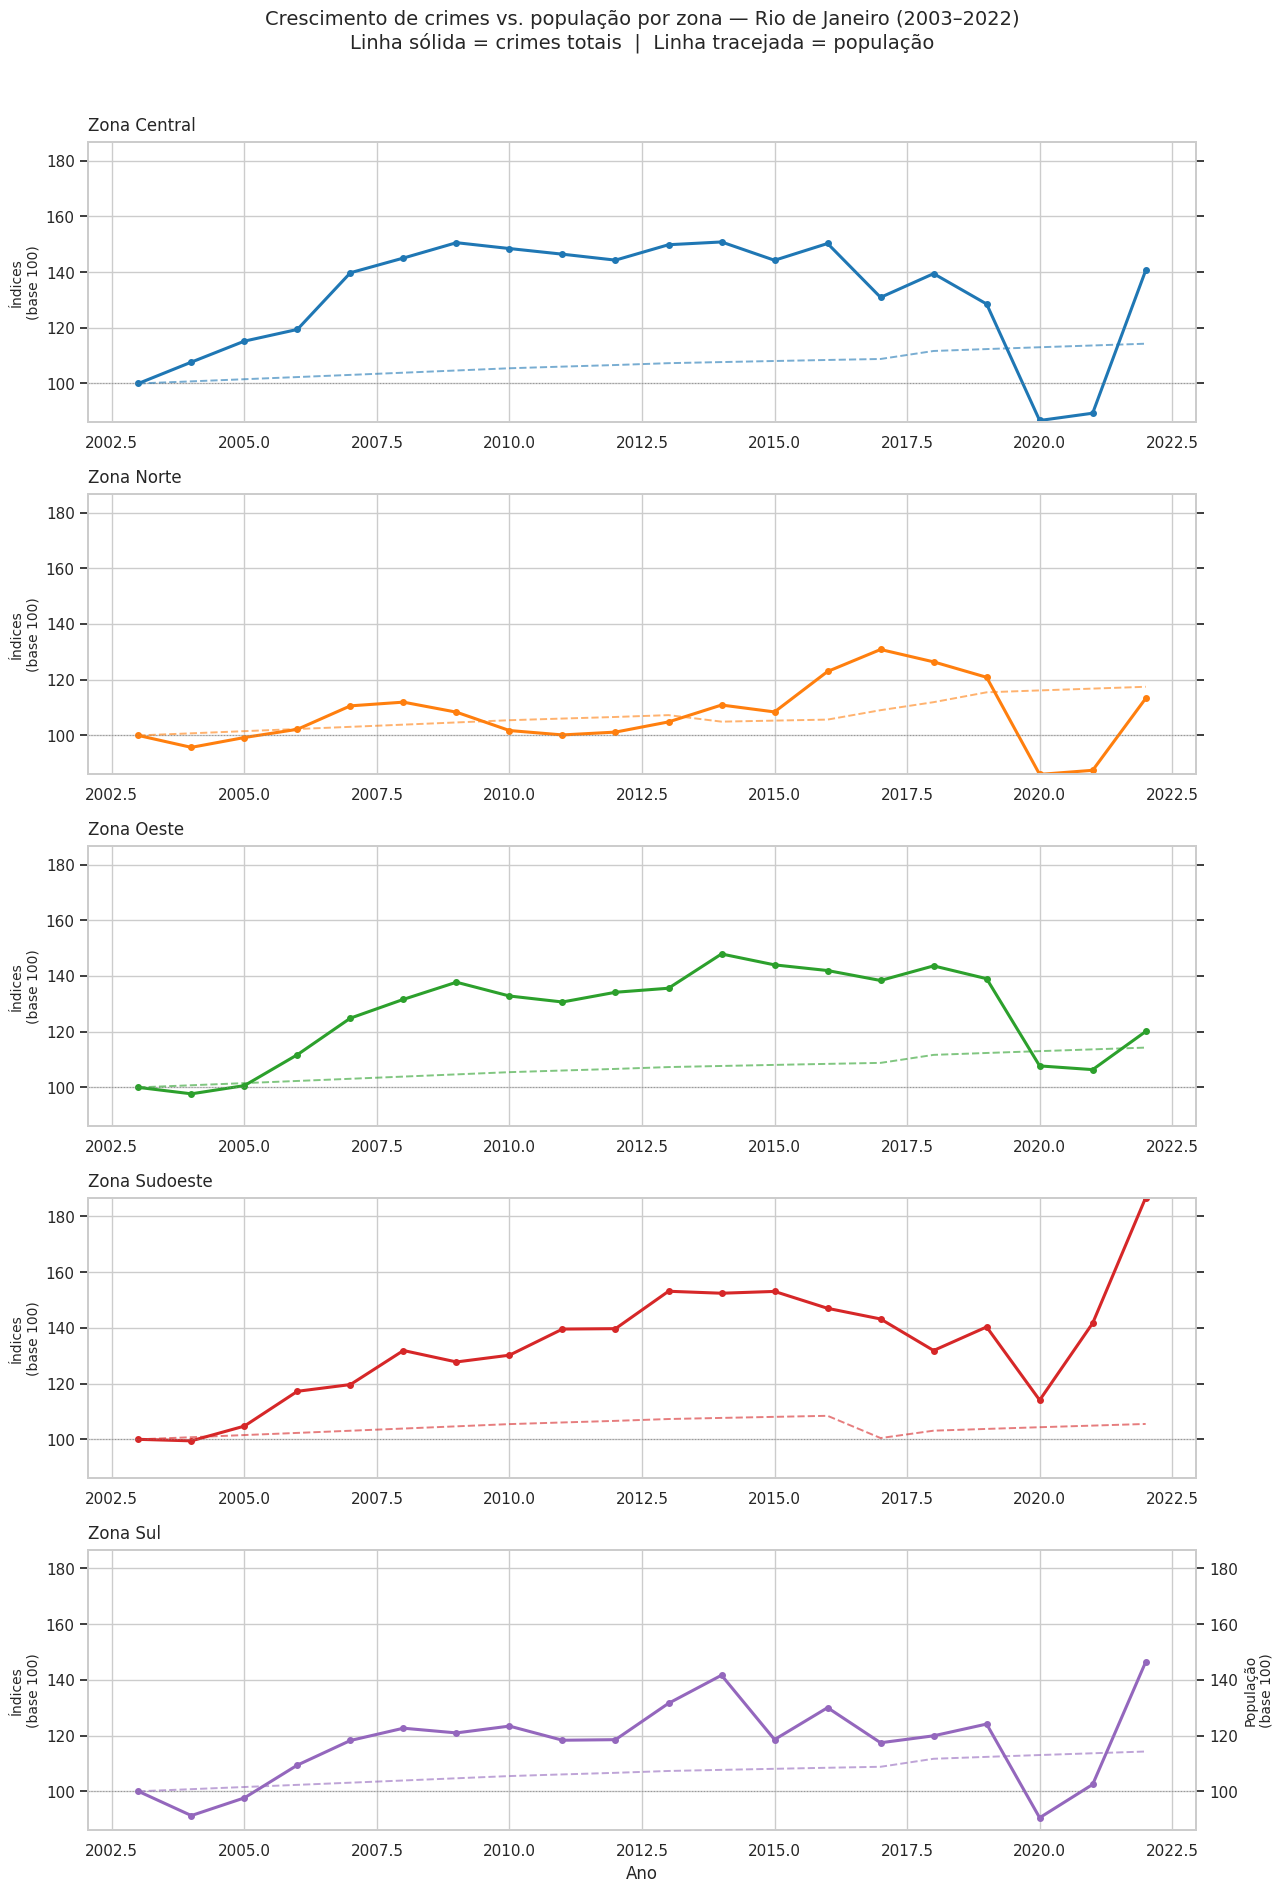


Variação acumulada 2003–2022 (índice base 100):
         Zona  Índice de crimes (2022)  Índice populacional (2022)
Zona Sudoeste               186.748882                  105.519367
     Zona Sul               146.419009                  114.279787
 Zona Central               140.580964                  114.280193
   Zona Oeste               120.061820                  114.280188
   Zona Norte               113.285104                  117.465218


In [113]:
# Estilo
sns.set_theme(style='whitegrid', palette='tab10')

zonas = sorted(df_com_pop['Zona'].unique())
cores = sns.color_palette('tab10', n_colors=len(zonas))
cor_por_zona = dict(zip(zonas, cores))

# 🔧 Definir escala global ANTES do loop
y_min = min(
    df_com_pop['indice_crimes'].min(),
    df_com_pop['indice_pop'].min()
)

y_max = max(
    df_com_pop['indice_crimes'].max(),
    df_com_pop['indice_pop'].max()
)

fig, axes = plt.subplots(
    nrows=len(zonas),
    ncols=1,
    figsize=(13, 3.8 * len(zonas)),
    sharex=False,
    sharey=True
)

if len(zonas) == 1:
    axes = [axes]

for ax, zona in zip(axes, zonas):
    dados = df_com_pop[df_com_pop['Zona'] == zona].sort_values('ano')
    cor = cor_por_zona[zona]

    ax_pop = ax.twinx()
    ax_pop.grid(False)

    # Linha sólida = índice de crimes
    ax.plot(
        dados['ano'], dados['indice_crimes'],
        color=cor, linewidth=2.2,
        marker='o', markersize=4,
        label='Índice de crimes'
    )

    # Linha tracejada = índice populacional
    ax_pop.plot(
        dados['ano'], dados['indice_pop'],
        color=cor, linewidth=1.4,
        linestyle='--', alpha=0.6,
        label='Índice populacional'
    )

    # 🔧 Aplicar MESMA escala nos dois eixos
    ax.set_ylim(y_min, y_max)
    ax_pop.set_ylim(y_min, y_max)

    # Linha base = 100
    ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

    # Título e labels
    ax.set_title(zona, loc='left', fontsize=12, pad=8)
    ax.set_ylabel('Índices\n(base 100)', fontsize=10)

    # Label do eixo direito (só no último, para não poluir)
    if ax != axes[-1]:
        ax_pop.set_yticklabels([])
        ax_pop.set_ylabel('')
    else:
        ax_pop.set_ylabel('População\n(base 100)', fontsize=10)

# Eixo X
axes[-1].set_xlabel('Ano', fontsize=12)

# Título geral
fig.suptitle(
    'Crescimento de crimes vs. população por zona — Rio de Janeiro (2003–2022)\n'
    'Linha sólida = crimes totais  |  Linha tracejada = população',
    fontsize=14,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Resumo 2022 (tabela)
print()
print('Variação acumulada 2003–2022 (índice base 100):')

resumo = df_com_pop[df_com_pop['ano'] == 2022][['Zona', 'indice_crimes', 'indice_pop']].copy()
resumo.columns = ['Zona', 'Índice de crimes (2022)', 'Índice populacional (2022)']
resumo = resumo.sort_values('Índice de crimes (2022)', ascending=False).reset_index(drop=True)

print(resumo.to_string(index=False))

Zona Central
* Crime cresce acima da população até meados de 2007, onde se estabelece num 'novo normal'.
* Mesmo desconsiderando o vale que a pandemia em 2020 representa, a criminalidade demonstra uma sutil queda desde 2017 (com um outlier em 2022).

Zona Norte
* Crescimento da ocorrência de crimes e crescimento da população igualmente sutis.
* Antes da óbvia queda na criminalidade durante a pandemia de 2020, o crime tem seu auge em 2017.

Zona Oeste
* O crime cresce acima da taxa da população mas só até meados de 2010. A partir daí, a distância é relativamente estável, sendo impactada apenas pela pandemia. Em outras palavras, foi criado um 'novo normal' nesta época, caracterizado por maior criminalidade do que no início do período registrado, em 2003.

Zona Sudoeste
* Crescimento da criminalidade significativamente maior que o crescimento populacional ao longo do período registrado (em relação ao observado nas outras zonas). Diferente da zona oeste, a distância entre os dois índices continuou se alargando até por volta de 2013.
* De alguma forma, o crime cresce exorbitantemente durante a pandemia (embora 2020 em si tenha representado uma queda)


Zona Sul
* Como na zona norte, os índices de criminalidade e de população não estão particularmente distantes um do outro (embora alguma distância tenha sido criada por volta de 2006).
* O crime também parece subir durante a pandemia (com a exceção do seu primeiro ano)

### Índices de Categoria de Crimes 2003-2022

In [103]:
# Precisamos reestruturar o dataframe pois agora agregaremos nas categorias de crime, e não zona
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

rio_ano = (
    df_com_pop.groupby('ano')[crime_cols + ['total_crimes', 'pop']]
    .sum()
    .reset_index()
)
rio_ano.head()

,ano,violentos,transito,roubos,furtos,outros,total_crimes,pop
0,2003,40694,17436,80415,60814,7160,206519,5992997
1,2004,39662,18014,75649,59196,8449,200970,6038713
2,2005,40985,16154,77033,65698,10361,210231,6084779
3,2006,39422,15692,81958,74775,12261,224108,6131201
4,2007,38813,18397,89217,84201,13970,244598,6177971


In [104]:
# Padronizando novamente

ano_base = 2003
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

# Linha do ano base
base = rio_ano[rio_ano['ano'] == ano_base].iloc[0]

# Índice da população
rio_ano['indice_pop'] = rio_ano['pop'] / base['pop'] * 100

# Índices de cada categoria
for col in crime_cols:
    rio_ano[f'indice_{col}'] = rio_ano[col] / base[col] * 100

In [105]:
rio_ano.head()

,ano,violentos,transito,roubos,furtos,outros,total_crimes,pop,indice_pop,indice_violentos,indice_transito,indice_roubos,indice_furtos,indice_outros
0,2003,40694,17436,80415,60814,7160,206519,5992997,100.0,100.000000,100.000000,100.000000,100.000000,100.000000
1,2004,39662,18014,75649,59196,8449,200970,6038713,100.762824,97.464000,103.314981,94.073245,97.339428,118.002793
2,2005,40985,16154,77033,65698,10361,210231,6084779,101.531488,100.715093,92.647396,95.794317,108.031045,144.706704
3,2006,39422,15692,81958,74775,12261,224108,6131201,102.306092,96.874232,89.997706,101.918796,122.956885,171.243017
4,2007,38813,18397,89217,84201,13970,244598,6177971,103.086502,95.377697,105.511585,110.945719,138.456605,195.111732


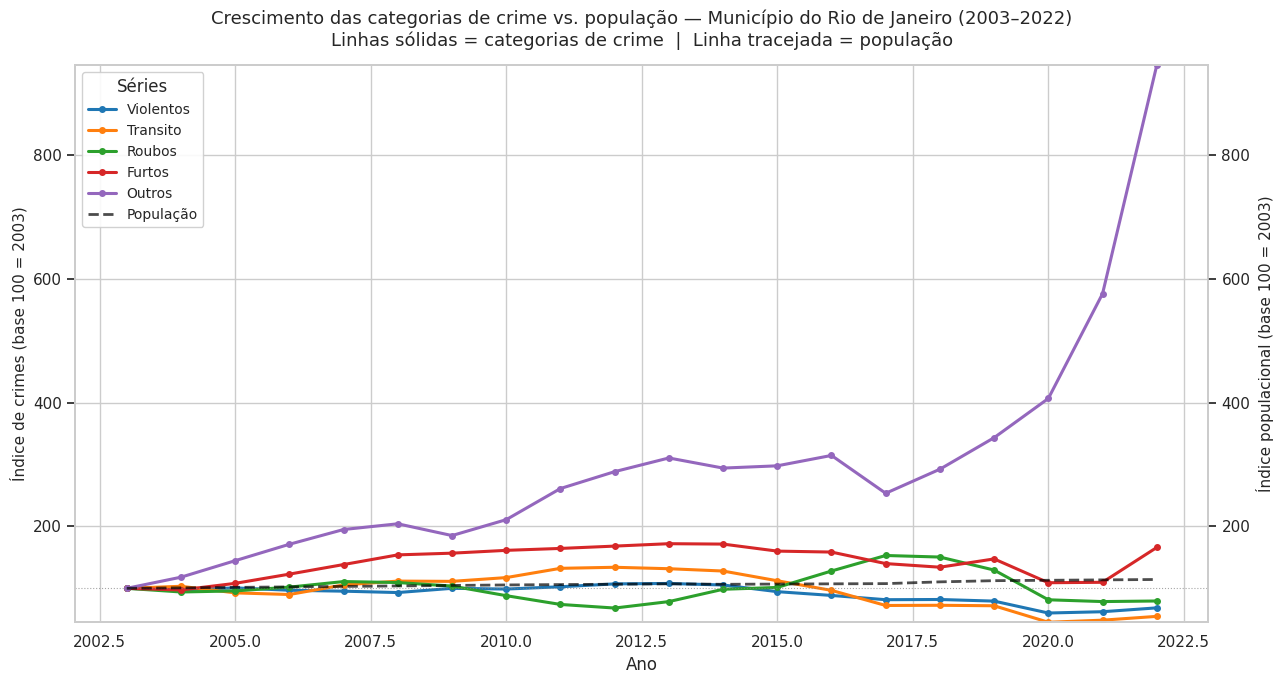


Variação acumulada 2003–2022 (índice base 100):
 indice_violentos  indice_transito  indice_roubos  indice_furtos  indice_outros  indice_pop
         68.39829         54.63409      79.511285     166.058802     945.712291  114.280101


In [106]:
# Estilo
sns.set_theme(style='whitegrid', palette='tab10')

crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']
cores = sns.color_palette('tab10', n_colors=len(crime_cols))
cor_por_categoria = dict(zip(crime_cols, cores))

# Figura
fig, ax = plt.subplots(figsize=(13, 7))
ax_pop = ax.twinx()
ax_pop.grid(False)

# Linhas das categorias de crime
for col in crime_cols:
    ax.plot(
        rio_ano['ano'], rio_ano[f'indice_{col}'],
        color=cor_por_categoria[col],
        linewidth=2.2,
        marker='o', markersize=4,
        label=col.capitalize()
    )

# Linha da população
ax_pop.plot(
    rio_ano['ano'], rio_ano['indice_pop'],
    color='black', linewidth=2,
    linestyle='--', alpha=0.7,
    label='População'
)

# Linha base = 100
ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

# Labels
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Índice de crimes (base 100 = 2003)', fontsize=11)
ax_pop.set_ylabel('Índice populacional (base 100 = 2003)', fontsize=11)

# Título
ax.set_title(
    'Crescimento das categorias de crime vs. população — Município do Rio de Janeiro (2003–2022)\n'
    'Linhas sólidas = categorias de crime  |  Linha tracejada = população',
    fontsize=13, pad=14
)

# Legenda unificada
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_pop.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left',
    fontsize=10,
    framealpha=0.9,
    title='Séries'
)

# Definir escala comum (baseada em TODOS os índices)
y_min = min(
    rio_ano[[f'indice_{col}' for col in crime_cols]].min().min(),
    rio_ano['indice_pop'].min()
)

y_max = max(
    rio_ano[[f'indice_{col}' for col in crime_cols]].max().max(),
    rio_ano['indice_pop'].max()
)

# Aplicar a mesma escala aos dois eixos
ax.set_ylim(y_min, y_max)
ax_pop.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()



# Resumo 2022 (tabela)
print()
print('Variação acumulada 2003–2022 (índice base 100):')

resumo = rio_ano[rio_ano['ano'] == 2022][['indice_violentos','indice_transito','indice_roubos','indice_furtos','indice_outros','indice_pop']].copy()
#resumo.columns = ['Zona', 'Índice de crimes (2022)', 'Índice populacional (2022)']
#resumo = resumo.sort_values('indice_crimes', ascending=False).reset_index(drop=True)

print(resumo.to_string(index=False))

Com os *outros crimes contra o patrimônio* crescendo de forma distintamente acelerada (por conta do crescimento do *estelionato*, como vimos na seção Média e Mediana), faz sentido montarmos uma visualização que exclui essa categoria, para melhor avaliarmos as diferenças das outras quatro.

De qualquer modo, podemos observar aqui que embora o crescimento da categoria 'outros crimes' sempre tenha sido superior ao das outras, ele só explode em meados de 2020, em paralelo com a pandemia de COVID-19.

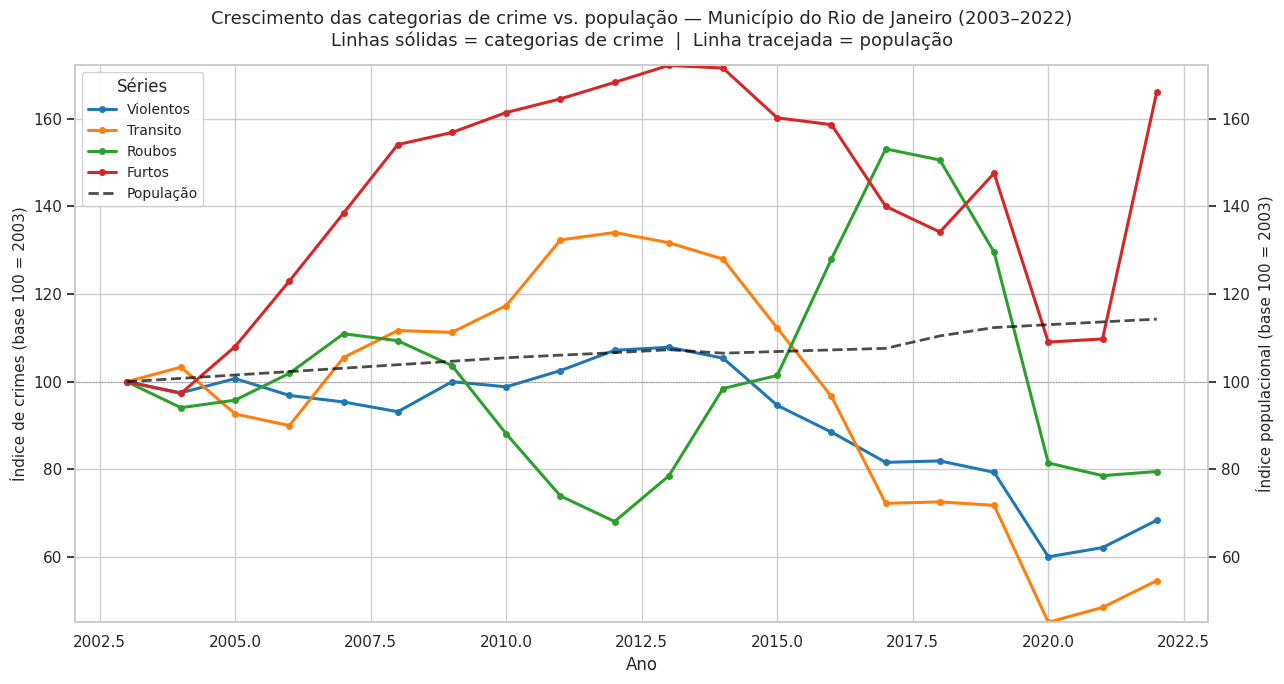


Variação acumulada 2003–2022 (índice base 100):
 indice_violentos  indice_transito  indice_roubos  indice_furtos  indice_pop
         68.39829         54.63409      79.511285     166.058802  114.280101


In [107]:
# Estilo
sns.set_theme(style='whitegrid', palette='tab10')

crime_cols2 = ['violentos', 'transito', 'roubos', 'furtos']
cores = sns.color_palette('tab10', n_colors=len(crime_cols2))
cor_por_categoria = dict(zip(crime_cols2, cores))

# Figura
fig, ax = plt.subplots(figsize=(13, 7))
ax_pop = ax.twinx()
ax_pop.grid(False)

# Linhas das categorias de crime
for col in crime_cols2:
    ax.plot(
        rio_ano['ano'], rio_ano[f'indice_{col}'],
        color=cor_por_categoria[col],
        linewidth=2.2,
        marker='o', markersize=4,
        label=col.capitalize()
    )

# Linha da população
ax_pop.plot(
    rio_ano['ano'], rio_ano['indice_pop'],
    color='black', linewidth=2,
    linestyle='--', alpha=0.7,
    label='População'
)

# Linha base = 100
ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

# Labels
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Índice de crimes (base 100 = 2003)', fontsize=11)
ax_pop.set_ylabel('Índice populacional (base 100 = 2003)', fontsize=11)

# Título
ax.set_title(
    'Crescimento das categorias de crime vs. população — Município do Rio de Janeiro (2003–2022)\n'
    'Linhas sólidas = categorias de crime  |  Linha tracejada = população',
    fontsize=13, pad=14
)

# Legenda unificada
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_pop.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left',
    fontsize=10,
    framealpha=0.9,
    title='Séries'
)

# Definir escala comum (baseada em TODOS os índices)
y_min = min(
    rio_ano[[f'indice_{col}' for col in crime_cols2]].min().min(),
    rio_ano['indice_pop'].min()
)

y_max = max(
    rio_ano[[f'indice_{col}' for col in crime_cols2]].max().max(),
    rio_ano['indice_pop'].max()
)

# Aplicar a mesma escala aos dois eixos
ax.set_ylim(y_min, y_max)
ax_pop.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# Resumo 2022 (tabela)
print()
print('Variação acumulada 2003–2022 (índice base 100):')

resumo = rio_ano[rio_ano['ano'] == 2022][['indice_violentos','indice_transito','indice_roubos','indice_furtos','indice_pop']].copy()
#resumo.columns = ['Zona', 'Índice de crimes (2022)', 'Índice populacional (2022)']
#resumo = resumo.sort_values('indice_crimes', ascending=False).reset_index(drop=True)

print(resumo.to_string(index=False))

In [ ]:
# Olhando o crime violento mais de perto
rio_ano[rio_ano['ano']>2013].loc[:,['ano','indice_violentos']]

,ano,indice_violentos
11,2014,105.371799
12,2015,94.601170
13,2016,88.494618
14,2017,81.604168
15,2018,81.935912
16,2019,79.326191
17,2020,60.062909
18,2021,62.159041
19,2022,68.398290


In [ ]:
# Olhando os roubos mais de perto
rio_ano[rio_ano['ano']>2003].loc[:,['ano','indice_roubos']]

,ano,indice_roubos
1,2004,94.073245
2,2005,95.794317
3,2006,101.918796
4,2007,110.945719
5,2008,109.353976
6,2009,103.662252
7,2010,88.121619
8,2011,73.940185
9,2012,68.107940
10,2013,78.536343


* Crimes Violentos: uma queda acentuada de 2014 a 2017, mesmo antes da pandemia, quando cai ainda mais por motivos óbvios.

* Crimes de trânsito: chegam a ter um pico em 2012 mas despencam a partir daí, atingindo um índice de por volta de 70 previamente à pandemia.

* Roubos: curiosamente, como um inverso dos crimes de transito, têm um vale em 2012 e daí partem para seu pico absoluto em 2017, antes de caírem no período pandêmico.

* Furtos: o crescimento desta categoria de crime excede o da população bem cedo no período, e intensamente. Pico em 2013, mas também cai antes mesmo da pandemia.

## Barras Empilhadas

Em *2025*, o ano completo mais representativo do presente. Não precisamos parar em 2022 desta vez pois em avaliar a razão relativa dos crimes por zona não precisamos dos dados populacionais.

In [114]:
# Soma dos crimes agrupados por zona no ano de 2025
crime_cols = ['violentos', 'transito', 'roubos', 'furtos', 'outros']

df_2025 = df[df['ano'] == 2025]

zona_crimes = (
    df_2025.groupby('Zona')[crime_cols]
    .sum()
)
zona_crimes.head()

,violentos,transito,roubos,furtos,outros
Zona,,,,,
Zona Central,2309,1310,6969,21309,6033
Zona Norte,12321,5535,34104,39875,27141
Zona Oeste,9801,3157,6995,12153,12019
Zona Sudoeste,5201,2719,8127,18626,18380
Zona Sul,2174,1178,5324,27110,11962


In [115]:
# Tabela com a participação percentual de cada categoria de crime
# Ex: Zona central = 6 + 3,5 + 18,3 + 56,2 + 15,9 = ~100%

zona_pct = zona_crimes.div(zona_crimes.sum(axis=1), axis=0) * 100
zona_pct.round(2).head()

,violentos,transito,roubos,furtos,outros
Zona,,,,,
Zona Central,6.09,3.45,18.37,56.18,15.91
Zona Norte,10.36,4.65,28.66,33.52,22.81
Zona Oeste,22.21,7.15,15.85,27.54,27.24
Zona Sudoeste,9.80,5.13,15.32,35.11,34.64
Zona Sul,4.55,2.47,11.15,56.78,25.05


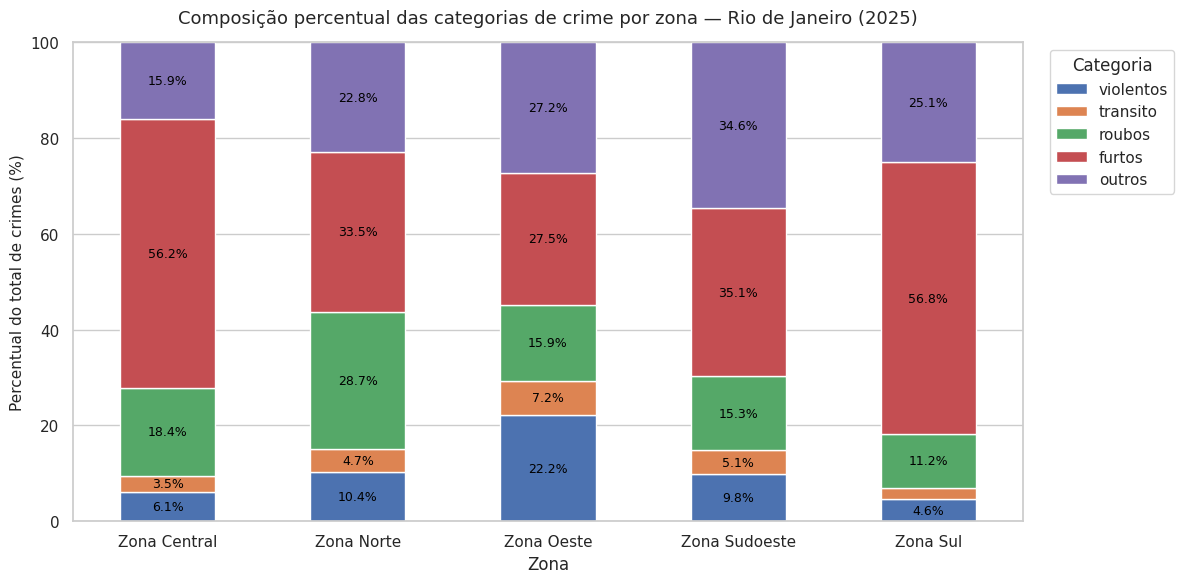

In [116]:
# Estilo
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

zona_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

# Adicionando rótulos percentuais
for i, zona in enumerate(zona_pct.index):
    acumulado = 0
    for col in zona_pct.columns:
        valor = zona_pct.loc[zona, col]

        if valor > 3:  # evita poluição visual (só mostra se >3%)
            ax.text(
                i,                      # posição no eixo x
                acumulado + valor / 2, # centro da "faixa"
                f'{valor:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

        acumulado += valor

ax.set_title(
    'Composição percentual das categorias de crime por zona — Rio de Janeiro (2025)',
    fontsize=13, pad=14
)

ax.set_ylabel('Percentual do total de crimes (%)', fontsize=11)

ax.legend(
    title='Categoria',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**O crime no Rio de Janeiro proliferou acima do crescimento populacional, como muitos pensam? Se sim, onde? Em quais categorias?**

=> Sim e não.

 Primeiramente, responder esta pergunta é delicado pois o dataset termina num momento ainda de instabilidade, logo após a pandemia de 2020. Sendo assim, é preciso dar atenção à tendência prévia a esta anomalia.

 Segundamente, esta resposta irá variar de acordo com a zona na cidade: **sim** para as zonas central, oeste e sudoeste, mas **não** (ou melhor, inconclusivo) para as demais zonas.

 E quando olhamos para as diferentes **categorias** de crime, fica evidente que os furtos e *especialmente* o estelionato cresceram acima da população, enquanto as categorias violentos, transito e roubo minguaram.

 (Veja a seção: Gráfico de Linhas)

## Hipótese 2


**Haveriam localidades 'outlier' em que o crime excede consideravelmente a média da sua respectiva zona?**

=> Sim.

Mesmo excluindo o outlier que é a unidade territorial "Centro (parte)", há diversas instâncias de unidades territoriais ocasionalmente até mesmo dobrando a média de suas regiões.

Dito isso, é importante considerar que isso não necessariamente significa que estes locais possuem alta criminalidade *constantemente*, visto que olhamos para as médias mensais do período como um todo. Isto pode significar apenas que estes são locais que *presenciaram* altas no crime significantes o suficiente para impactar as suas médias.

(Veja a seção: Média e Mediana)

## Hipótese 3

**A composição da criminalidade é significativamente diferente entre zonas?**

=> Sim.

*Crimes violentos* são pouco expressivos com excessão da **zona oeste**, em que chegam a 22% do total dos crimes. *Crimes de transito* são inexpressivos de modo geral, mas há um destaque relativo da zona oeste nesta categoria também, aos 7,2%.

*Roubos* chegam a possuir mais que o dobro da participação na **zona norte** em comparação com a zona sul - 28,7% em contraste com 11,2%.

*Furtos* são quase três quintos dos crimes na **zona sul** (57%), enquanto estão pouco acima de um quinto na zona oeste (27,5%). Possuem participação considerável em todas as zonas, no entanto.

*Outros crimes* (categoria puxada pelo estelionato), têm seu mínimo em próximo de 16% de participação, na zona central, e seu máximo na **zona sudoeste**, onde brigam pela primeira posição com os furtos em por volta de 35%.

(Veja a seção: Barras Empilhadas)

# Conclusão

O projeto foi bem-sucedido em abordar cada uma de suas três hipóteses, o que só foi possível graças ao trabalho de união (join) dos diferentes dataframes e o trabalho de pré-processamento, em que os mais que mil valores faltantes foram abordados. A hipótese 1 exigia um olhar na dimensão do tempo, portanto um gráfico de linhas fez-se essencial. A hipótese 2, a mais granular do trio, pôde ser respondida com uma tabela de 'top 5' unidades territoriais com mais de um determinado crime. Por fim, a hipótese 3, que se referia à composição do crime, pôde ser bem respondida com um gráfico de barras empilhadas padronizado, isto é, em que o total de cada barra se equivalia, visto que as partes estavam em porcentagem.

Dito isso, o atual projeto explora apenas a superfície deste conjunto de datasets. Há muito a ser investigado ainda, especialmente em dois frontes:

1) A granularidade dos dados: o estelionato foi um crime específico que claramente se destacou, mas que outros crimes específicos merecem investigação mais detalhada? E as unidades territoriais?

2) Dimensão temporal: mesmo considerando que plotei gráficos de linha e preparei o dataset para uma regressão, restam muitas dúvidas a respeito não dos valores absolutos, mas as taxas de crescimento dos crimes.

<br>

Obrigado pela leitura!